# IRBF

The purpose of this notebook is to test the main notebook with a limit of 500 GHz without secondary rescattering to understand the impact of our secondary-scattering correction.

## Imports, Definitions, and loading data

In [67]:
## Critical Imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import cmasher as cmr

import scipy.constants as const
# from scipy.optimize import curve_fit
import pandas as pd
from matplotlib.ticker import MultipleLocator, ScalarFormatter
from scipy.signal import find_peaks
from itertools import cycle

# Nested Sampling
import dynesty
import corner
import pickle
import os

#Aesthetics
import matplotlib as mpl
plt.style.use('style.mplstyle')

# My stuff
from TeraToptica import TeraFlashAnalyzer as TFA, TeraFlashConfig as TFC
from TeraToptica import TeraScanAnalyzer as TSA, TeraScanConfig as TSC

window = 'gaussian' # Smoothing window type in frequency domain
window_size  = 15 # Determines how many GHz to smooth the spectrum over (upper bound)

mask_bounds = ((0, 150), (500, 10000))

f = np.arange(5, 500.1, 1)

batches = {}

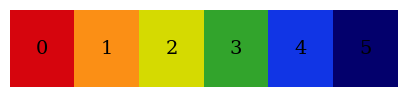

In [68]:
from cmap import Colormap
cmap = Colormap('colorcet:CET_R4')
# cmap = cmr.horizon
# cmap = Colormap('magma')


cmap_array = cmap(np.linspace(0, 1, 256))[::-1]

entries = 6
indices = np.linspace(0, len(cmap_array)-1, entries).astype(int)
colors2 = cmap_array[indices]

# Display for visualization
large_font = 14  # font size for labels
plt.figure(figsize=(5, 1))
plt.imshow([colors2], aspect='auto')

for i in range(len(colors2)):  # one less because we skipped first color
    plt.annotate(i, (i, 0), color='k', fontsize=large_font, ha='center', va='center')

plt.gca().set_axis_off()

# =========================
# Colormap infrastructure
# =========================

# HD30 default colormaps (Batch1, Batch2, Batch3)
def apply_cmap(bname, cmap, lo=0.4, hi=0.85, mean_pos=0.6):
    sample_dict = batches[bname]

    keys = list(sample_dict.keys())
    cols = cmap(np.linspace(lo, hi, len(keys)))
    cols = cols[::-1]

    for s, c in zip(keys, cols):
        sample_dict[s]["color"] = c

    comb_batches[bname]["color"] = cmap(mean_pos)

In [69]:
from matplotlib.colors import to_rgb
import colorsys

# Linearly steps through value, works best with high saturation colors
def get_colors(N, stop_color, start_v=1, stop_v=0.5):
    r, g, b = to_rgb(stop_color)
    h, s, _ = colorsys.rgb_to_hsv(r, g, b)

    v_values = np.linspace(start_v, stop_v, N)
    colors = [colorsys.hsv_to_rgb(h, s, v) for v in v_values]
    return np.array(colors)

### Styrofoam

In [70]:
tf_cfg = TFC(
    window=window,
    window_size=window_size,
    mask_bounds=mask_bounds,
    layout='reference_included'
)

tf_cfg2 = TFC(
    window=window,
    window_size=window_size,
    mask_bounds=mask_bounds,
    layout='separate_files'
)

#These were NOT cycled in a vacuum chamber

path = './data/20260605/' #Check the repeatability of the thin styrofoams

styro_0o8mm  = TFA(path, 'styro_thin1_0o8mm_1850-2050ps_100avgs', config=tf_cfg)
styro_1o5mm  = TFA(path, 'styro_thin2_1o5mm_1850-2050ps_100avgs', config=tf_cfg)

styro_6o1mm  = TFA(path, 'styro_6o1mm_1850-2050ps_100avgs',  config=tf_cfg)

styro_13o5mm = TFA(path, 'styro_13o5mm_1850-2050ps_100avgs', config=tf_cfg)
styro_42o3mm = TFA(path, 'styro_filter_1850-2050ps_100avgs', config=tf_cfg)

# Data beyond this point was deployed for initial SATp2 observations
path = './data/20260518/'

SATp2_site_sample4_1_45o3mm = TFA(path, 'satp2_site_sample4_1_45o3mm_2210-2410ps_100avgs', 'open_2210-2410ps_100avgs', config=tf_cfg2)

path = './data/20260529/'
base = 'open2_1850-2050ps_100avgs'

sample4_thick_5o8mm = TFA(path, 'SATp2_site_sample4_5o8mm_2_1850-2050ps_100avgs', base, config=tf_cfg2)
sample4_thin_16o2mm = TFA(path, 'SATp2_site_sample4_16o2mm_2_1850-2050ps_100avgs', base, config=tf_cfg2)
sample4_thin_16o9mm = TFA(path, 'SATp2_site_sample4_16o9mm_1850-2050ps_100avgs', base, config=tf_cfg2)
sample4_thick_5o6mm = TFA(path, 'SATp2_site_sample4_5o6mm_1850-2050ps_100avgs', base, config=tf_cfg2)

## Frequency domain data for Styrofoam
f_0o8mm,  t_0o8mm,  ut_0o8mm,  mask_0o8mm,  err_0o8mm,  boxnum_0o8mm  = styro_0o8mm.get_smoothed_spectra()
f_1o5mm,  t_1o5mm,  ut_1o5mm,  mask_1o5mm,  err_1o5mm,  boxnum_1o5mm  = styro_1o5mm.get_smoothed_spectra()
f_6o1mm,  t_6o1mm,  ut_6o1mm,  mask_6o1mm,  err_6o1mm,  boxnum_6o1mm  = styro_6o1mm.get_smoothed_spectra()
f_13o5mm, t_13o5mm, ut_13o5mm, mask_13o5mm, err_13o5mm, boxnum_13o5mm = styro_13o5mm.get_smoothed_spectra()
f_42o3mm, t_42o3mm, ut_42o3mm, mask_42o3mm, err_42o3mm, boxnum_42o3mm = styro_42o3mm.get_smoothed_spectra()
f_45o3mm, t_45o3mm, ut_45o3mm, mask_45o3mm, err_45o3mm, boxnum_45o3mm = SATp2_site_sample4_1_45o3mm.get_smoothed_spectra()
f_5o8mm,  t_5o8mm,  ut_5o8mm,  mask_5o8mm,  err_5o8mm,  boxnum_5o8mm  = sample4_thick_5o8mm.get_smoothed_spectra()
f_16o2mm, t_16o2mm, ut_16o2mm, mask_16o2mm, err_16o2mm, boxnum_16o2mm = sample4_thin_16o2mm.get_smoothed_spectra()
f_16o9mm, t_16o9mm, ut_16o9mm, mask_16o9mm, err_16o9mm, boxnum_16o9mm = sample4_thin_16o9mm.get_smoothed_spectra()
f_5o6mm,  t_5o6mm,  ut_5o6mm,  mask_5o6mm,  err_5o6mm,  boxnum_5o6mm  = sample4_thick_5o6mm.get_smoothed_spectra()


## Time domain data for Styrofoam
T_0o8mm,  pc_0o8mm  = styro_0o8mm.get_sample_pulse()
T_1o5mm,  pc_1o5mm  = styro_1o5mm.get_sample_pulse()
T_6o1mm,  pc_6o1mm  = styro_6o1mm.get_sample_pulse()
T_13o5mm, pc_13o5mm = styro_13o5mm.get_sample_pulse()
T_42o3mm, pc_42o3mm = styro_42o3mm.get_sample_pulse()
T_45o3mm, pc_45o3mm = SATp2_site_sample4_1_45o3mm.get_sample_pulse()
T_5o8mm,  pc_5o8mm  = sample4_thick_5o8mm.get_sample_pulse()
T_16o2mm, pc_16o2mm = sample4_thin_16o2mm.get_sample_pulse()
T_16o9mm, pc_16o9mm = sample4_thin_16o9mm.get_sample_pulse()
T_5o6mm,  pc_5o6mm  = sample4_thick_5o6mm.get_sample_pulse()

# Phase data for Styrofoam
theta_0o8mm,  theta_base_0o8mm  = styro_0o8mm.get_phases()
theta_1o5mm,  theta_base_1o5mm  = styro_1o5mm.get_phases()
theta_6o1mm,  theta_base_6o1mm  = styro_6o1mm.get_phases()
theta_13o5mm, theta_base_13o5mm = styro_13o5mm.get_phases()
theta_42o3mm, theta_base_42o3mm = styro_42o3mm.get_phases()
theta_45o3mm, theta_base_45o3mm = SATp2_site_sample4_1_45o3mm.get_phases()
theta_5o8mm,  theta_base_5o8mm  = sample4_thick_5o8mm.get_phases()
theta_16o2mm, theta_base_16o2mm = sample4_thin_16o2mm.get_phases()
theta_16o9mm, theta_base_16o9mm = sample4_thin_16o9mm.get_phases()
theta_5o6mm,  theta_base_5o6mm  = sample4_thick_5o6mm.get_phases()

Styrofoam_batch = {}

Styrofoam_batch["Styrofoam 0.08 cm"] = {'f': f_0o8mm,  't': t_0o8mm,  'ut': ut_0o8mm,  'mask': mask_0o8mm,  'err': err_0o8mm,  'boxnum': boxnum_0o8mm,  'T': T_0o8mm,  'pc': pc_0o8mm,  'theta': theta_0o8mm,  'theta_base': theta_base_0o8mm,  'width': 0.08}
Styrofoam_batch["Styrofoam 0.15 cm"] = {'f': f_1o5mm,  't': t_1o5mm,  'ut': ut_1o5mm,  'mask': mask_1o5mm,  'err': err_1o5mm,  'boxnum': boxnum_1o5mm,  'T': T_1o5mm,  'pc': pc_1o5mm,  'theta': theta_1o5mm,  'theta_base': theta_base_1o5mm,  'width': 0.15}
Styrofoam_batch["Styrofoam 0.61 cm"] = {'f': f_6o1mm,  't': t_6o1mm,  'ut': ut_6o1mm,  'mask': mask_6o1mm,  'err': err_6o1mm,  'boxnum': boxnum_6o1mm,  'T': T_6o1mm,  'pc': pc_6o1mm,  'theta': theta_6o1mm,  'theta_base': theta_base_6o1mm,  'width': 0.61}
Styrofoam_batch["Styrofoam 1.35 cm"] = {'f': f_13o5mm, 't': t_13o5mm, 'ut': ut_13o5mm, 'mask': mask_13o5mm, 'err': err_13o5mm, 'boxnum': boxnum_13o5mm, 'T': T_13o5mm, 'pc': pc_13o5mm, 'theta': theta_13o5mm, 'theta_base': theta_base_13o5mm, 'width': 1.35}
Styrofoam_batch["Styrofoam 4.23 cm"] = {'f': f_42o3mm, 't': t_42o3mm, 'ut': ut_42o3mm, 'mask': mask_42o3mm, 'err': err_42o3mm, 'boxnum': boxnum_42o3mm, 'T': T_42o3mm, 'pc': pc_42o3mm, 'theta': theta_42o3mm, 'theta_base': theta_base_42o3mm, 'width': 4.23}
Styrofoam_batch['Styrofoam 0.56 cm'] = {'f': f_5o6mm,  't': t_5o6mm,  'ut': ut_5o6mm,  'mask': mask_5o6mm,  'err': err_5o6mm,  'boxnum': boxnum_5o6mm,  'T': T_5o6mm,  'pc': pc_5o6mm,  'theta': theta_5o6mm,  'theta_base': theta_base_5o6mm,  'width': 0.56}
Styrofoam_batch['Styrofoam 0.58 cm'] = {'f': f_5o8mm,  't': t_5o8mm,  'ut': ut_5o8mm,  'mask': mask_5o8mm,  'err': err_5o8mm,  'boxnum': boxnum_5o8mm,  'T': T_5o8mm,  'pc': pc_5o8mm,  'theta': theta_5o8mm,  'theta_base': theta_base_5o8mm,  'width': 0.58}
Styrofoam_batch['Styrofoam 1.62 cm'] = {'f': f_16o2mm, 't': t_16o2mm, 'ut': ut_16o2mm, 'mask': mask_16o2mm, 'err': err_16o2mm, 'boxnum': boxnum_16o2mm, 'T': T_16o2mm, 'pc': pc_16o2mm, 'theta': theta_16o2mm, 'theta_base': theta_base_16o2mm, 'width': 1.62}
Styrofoam_batch['Styrofoam 1.69 cm'] = {'f': f_16o9mm, 't': t_16o9mm, 'ut': ut_16o9mm, 'mask': mask_16o9mm, 'err': err_16o9mm, 'boxnum': boxnum_16o9mm, 'T': T_16o9mm, 'pc': pc_16o9mm, 'theta': theta_16o9mm, 'theta_base': theta_base_16o9mm, 'width': 1.69}
Styrofoam_batch['Styrofoam 4.53 cm'] = {'f': f_45o3mm, 't': t_45o3mm, 'ut': ut_45o3mm, 'mask': mask_45o3mm, 'err': err_45o3mm, 'boxnum': boxnum_45o3mm, 'T': T_45o3mm, 'pc': pc_45o3mm, 'theta': theta_45o3mm, 'theta_base': theta_base_45o3mm, 'width': 4.53}

batches['Styrofoam_batch'] = Styrofoam_batch

### HD30_batch1

In [71]:
# TeraFlashAnalyzer Instances for HD30_batch1
path = './data/20251216/'
penn_3o47mm    = TFA(path, 'HD30_1x0o125in_3o47mm_penn_1675-1875ps_100avgs', config=tf_cfg)

path = './data/20260212'
penn_6o51mm  = TFA(path, 'hd30_penn_6o51mm_1400-1600ps_100avgs', config=tf_cfg) # 2x1/8"
penn_27o6mm  = TFA(path, 'hd30_penn_27o60mm_1400-1600ps_100avgs', config=tf_cfg) # 8x1/8"
penn_30o94mm = TFA(path, 'hd30_penn_30o94mm_1400-1600ps_100avgs', config=tf_cfg) # 10x1/8

# Frequency domain data for HD30_batch1
f_3o47mm,  t_3o47mm,  ut_3o47mm,  mask_3o47mm,  err_3o47mm,  boxnum_3o47mm  = penn_3o47mm.get_smoothed_spectra()
f_6o51mm,  t_6o51mm,  ut_6o51mm,  mask_6o51mm,  err_6o51mm,  boxnum_6o51mm  = penn_6o51mm.get_smoothed_spectra()
f_27o6mm,  t_27o6mm,  ut_27o6mm,  mask_27o6mm,  err_27o6mm,  boxnum_27o6mm  = penn_27o6mm.get_smoothed_spectra()
f_30o94mm, t_30o94mm, ut_30o94mm, mask_30o94mm, err_30o94mm, boxnum_30o94mm = penn_30o94mm.get_smoothed_spectra()

# Time domain data for HD30_batch1
T_3o47mm,  pc_3o47mm  = penn_3o47mm.get_sample_pulse()
T_6o51mm,  pc_6o51mm  = penn_6o51mm.get_sample_pulse()
T_27o6mm,  pc_27o6mm  = penn_27o6mm.get_sample_pulse()
T_30o94mm, pc_30o94mm = penn_30o94mm.get_sample_pulse()

# Phase data for HD30_batch1
theta_3o47mm,  theta_base_3o47mm  = penn_3o47mm.get_phases()
theta_6o51mm,  theta_base_6o51mm  = penn_6o51mm.get_phases()
theta_27o6mm,  theta_base_27o6mm  = penn_27o6mm.get_phases()
theta_30o94mm, theta_base_30o94mm = penn_30o94mm.get_phases()

HD30_batch1 = {}
HD30_batch1['HD30 batch1 0.35 cm'] = {'f': f_3o47mm,  't': t_3o47mm,  'ut': ut_3o47mm,  'mask': mask_3o47mm,  'err': err_3o47mm,  'boxnum': boxnum_3o47mm,  'T': T_3o47mm,  'pc': pc_3o47mm,  'theta_base': theta_base_3o47mm,  'theta': theta_3o47mm,  'width': 0.347}
HD30_batch1['HD30 batch1 0.65 cm'] = {'f': f_6o51mm,  't': t_6o51mm,  'ut': ut_6o51mm,  'mask': mask_6o51mm,  'err': err_6o51mm,  'boxnum': boxnum_6o51mm,  'T': T_6o51mm,  'pc': pc_6o51mm,  'theta_base': theta_base_6o51mm,  'theta': theta_6o51mm,  'width': 0.651}
HD30_batch1['HD30 batch1 2.76 cm'] = {'f': f_27o6mm,  't': t_27o6mm,  'ut': ut_27o6mm,  'mask': mask_27o6mm,  'err': err_27o6mm,  'boxnum': boxnum_27o6mm,  'T': T_27o6mm,  'pc': pc_27o6mm,  'theta_base': theta_base_27o6mm,  'theta': theta_27o6mm,  'width': 2.76}
HD30_batch1['HD30 batch1 3.09 cm'] = {'f': f_30o94mm, 't': t_30o94mm, 'ut': ut_30o94mm, 'mask': mask_30o94mm, 'err': err_30o94mm, 'boxnum': boxnum_30o94mm, 'T': T_30o94mm, 'pc': pc_30o94mm, 'theta_base': theta_base_30o94mm, 'theta': theta_30o94mm, 'width': 3.094}

batches['HD30_batch1'] = HD30_batch1

### HD30_batch2

In [72]:
path = './data/20251216/'

## TeraFlashAnalyzer Instances for HD30_batch2
cornell_3o65mm = TFA(path, 'hd30_1x0o125in_3o65mm_cornell_1675-1875ps_100avgs', config = tf_cfg)
cornell_7o3mm  = TFA(path, 'hd30_2x0o125in_7o3mm_cornell_1675-1875ps_100avgs',  config = tf_cfg)
cornell_25o4mm = TFA(path, 'hd30_1x1in_25o4mm_cornell2_1675-1875ps_100avgs',    config = tf_cfg)

## Frequency domain data for HD30_batch2
f_3o65mm, t_3o65mm,  ut_3o65mm,  mask_3o65mm,  err_3o65mm,  boxnum_3o65mm  = cornell_3o65mm.get_smoothed_spectra()
f_7o3mm,  t_7o3mm,   ut_7o3mm,   mask_7o3mm,   err_7o3mm,   boxnum_7o3mm   = cornell_7o3mm.get_smoothed_spectra()
f_25o4mm, t_25o4mm,  ut_25o4mm,  mask_25o4mm,  err_25o4mm,  boxnum_25o4mm  = cornell_25o4mm.get_smoothed_spectra()

## Time domain data for HD30_batch2
T_3o65mm,  pc_3o65mm  = cornell_3o65mm.get_sample_pulse()
T_7o3mm,   pc_7o3mm   = cornell_7o3mm.get_sample_pulse()
T_25o4mm,  pc_25o4mm  = cornell_25o4mm.get_sample_pulse()

## Phase data for HD30_batch2
theta_3o65mm, theta_base_3o65mm = cornell_3o65mm.get_phases()
theta_7o3mm,  theta_base_7o3mm  = cornell_7o3mm.get_phases()
theta_25o4mm, theta_base_25o4mm = cornell_25o4mm.get_phases()

HD30_batch2 = {}

HD30_batch2['HD30 batch2 0.37 cm'] = {'f': f_3o65mm, 't': t_3o65mm, 'ut': ut_3o65mm, 'mask': mask_3o65mm, 'err': err_3o65mm, 'boxnum': boxnum_3o65mm, 'T': T_3o65mm, 'pc': pc_3o65mm, 'theta_base': theta_base_3o65mm, 'theta': theta_3o65mm, 'width': 0.365}
HD30_batch2['HD30 batch2 0.73 cm'] = {'f': f_7o3mm,  't': t_7o3mm,  'ut': ut_7o3mm,  'mask': mask_7o3mm,  'err': err_7o3mm,  'boxnum': boxnum_7o3mm,  'T': T_7o3mm,  'pc': pc_7o3mm,  'theta_base': theta_base_7o3mm,  'theta': theta_7o3mm,  'width': 0.73}
HD30_batch2['HD30 batch2 2.54 cm'] = {'f': f_25o4mm, 't': t_25o4mm, 'ut': ut_25o4mm, 'mask': mask_25o4mm, 'err': err_25o4mm, 'boxnum': boxnum_25o4mm, 'T': T_25o4mm, 'pc': pc_25o4mm, 'theta_base': theta_base_25o4mm, 'theta': theta_25o4mm, 'width': 2.54}

batches['HD30_batch2'] = HD30_batch2

### HD30_batch3
Deployed for ASO

In [73]:
path = './data/20251216/'

site_3o58mm    = TFA(path, 'HD30_1x0o125in_3o58mm_site_1675-1875ps_100avgs',  config=tf_cfg)
site_7o18mm    = TFA(path, 'HD30_2x0o125in_7o18mm_site_1675-1875ps_100avgs',  config=tf_cfg)
site_10o86mm   = TFA(path, 'HD30_3x0o125in_10o86mm_site_1675-1875ps_100avgs', config=tf_cfg)
site_25o4mm    = TFA(path, 'HD30_1x1in_25o4mm_site_1675-1875ps_100avgs',      config=tf_cfg)
site_50o9mm    = TFA(path, 'HD30_2x1in_50o9mm_site_1675-1875ps_100avgs',      config=tf_cfg)

## Frequency domain data for HD30_batch3 
f_3o58mm,  t_3o58mm,  ut_3o58mm,  mask_3o58mm,  err_3o58mm,  boxnum_3o58mm  = site_3o58mm.get_smoothed_spectra()
f_7o18mm,  t_7o18mm,  ut_7o18mm,  mask_7o18mm,  err_7o18mm,  boxnum_7o18mm  = site_7o18mm.get_smoothed_spectra()
f_10o86mm, t_10o86mm, ut_10o86mm, mask_10o86mm, err_10o86mm, boxnum_10o86mm = site_10o86mm.get_smoothed_spectra()
f_25o4mm,  t_25o4mm,  ut_25o4mm,  mask_25o4mm,  err_25o4mm,  boxnum_25o4mm  = site_25o4mm.get_smoothed_spectra()
f_50o9mm,  t_50o9mm,  ut_50o9mm,  mask_50o9mm,  err_50o9mm,  boxnum_50o9mm  = site_50o9mm.get_smoothed_spectra()

## Time domain data for HD30_batch3 
T_3o58mm,  pc_3o58mm  = site_3o58mm.get_sample_pulse()
T_7o18mm,  pc_7o18mm  = site_7o18mm.get_sample_pulse()
T_10o86mm, pc_10o86mm = site_10o86mm.get_sample_pulse()
T_25o4mm,  pc_25o4mm  = site_25o4mm.get_sample_pulse()
T_50o9mm,  pc_50o9mm  = site_50o9mm.get_sample_pulse()

# Phase HD30_batch3
theta_3o58mm, theta_base_3o58mm   = site_3o58mm.get_phases()
theta_7o18mm, theta_base_7o18mm   = site_7o18mm.get_phases()
theta_10o86mm, theta_base_10o86mm = site_10o86mm.get_phases()
theta_25o4mm, theta_base_25o4mm   = site_25o4mm.get_phases()
theta_50o9mm, theta_base_50o9mm   = site_50o9mm.get_phases()

HD30_batch3 = {}

HD30_batch3['HD30 batch3 0.36 cm'] = {'f': f_3o58mm,  't': t_3o58mm,  'ut': ut_3o58mm,  'mask': mask_3o58mm,  'err': err_3o58mm,  'boxnum': boxnum_3o58mm,  'T': T_3o58mm,  'pc': pc_3o58mm,  'theta': theta_3o58mm,  'theta_base': theta_base_3o58mm,  'width': 0.358}
HD30_batch3['HD30 batch3 0.72 cm'] = {'f': f_7o18mm,  't': t_7o18mm,  'ut': ut_7o18mm,  'mask': mask_7o18mm,  'err': err_7o18mm,  'boxnum': boxnum_7o18mm,  'T': T_7o18mm,  'pc': pc_7o18mm,  'theta': theta_7o18mm,  'theta_base': theta_base_7o18mm,  'width': 0.718}
HD30_batch3['HD30 batch3 1.09 cm'] = {'f': f_10o86mm, 't': t_10o86mm, 'ut': ut_10o86mm, 'mask': mask_10o86mm, 'err': err_10o86mm, 'boxnum': boxnum_10o86mm, 'T': T_10o86mm, 'pc': pc_10o86mm, 'theta': theta_10o86mm, 'theta_base': theta_base_10o86mm, 'width': 1.086}
HD30_batch3['HD30 batch3 2.54 cm'] = {'f': f_25o4mm,  't': t_25o4mm,  'ut': ut_25o4mm,  'mask': mask_25o4mm,  'err': err_25o4mm,  'boxnum': boxnum_25o4mm,  'T': T_25o4mm,  'pc': pc_25o4mm,  'theta': theta_25o4mm,  'theta_base': theta_base_25o4mm,  'width': 2.54}
HD30_batch3['HD30 batch3 5.09 cm'] = {'f': f_50o9mm,  't': t_50o9mm,  'ut': ut_50o9mm,  'mask': mask_50o9mm,  'err': err_50o9mm,  'boxnum': boxnum_50o9mm,  'T': T_50o9mm,  'pc': pc_50o9mm,  'theta': theta_50o9mm,  'theta_base': theta_base_50o9mm,  'width': 5.09}

batches['HD30_batch3'] = HD30_batch3

### Other densities of Zote

In [74]:
path = './data/20251117/' #Path to the data directory

LD15_1in  = TFA(path, 'LD15_1590-1790ps_1000avgs',  config=tf_cfg)
LD24_1in  = TFA(path, 'LD24_1590-1790ps_1000avgs',  config=tf_cfg)
HD80_1in  = TFA(path, 'HD80_1590-1790ps_1000avgs',  config=tf_cfg)
HD110_1in = TFA(path, 'HD110_1590-1790ps_1000avgs', config=tf_cfg)

path = './data/cornell/'

# We use a legacy TeraScan measurement for HD60, HD60 was firmly rejected before the TeraFlash was installed.
HD60_1in  = TSA(path,   
                'TestData_2050225_Zotefoam_HD60_0p8in_300K_Sample_100to1000GHz_Step200MHz_Scan_0001.dat',  
                'TestData_2050225_Zotefoam_HD60_0p8in_300K_ClrBg_100to1000GHz_Step200MHz_Scan_0001.dat',
                config=TSC(window=window, window_size=window_size, mask_bounds=mask_bounds, fiber_stretcher=True))

path = './data/20260612/'

LD15_ucsd_3o0mm = TFA(path, 'LD15_ucsd_1850-2050ps_100avgs', config=tf_cfg)
LD24_ucsd_3o4mm = TFA(path, 'LD24_ucsd_1850-2050ps_100avgs', config=tf_cfg)

## Frequency-domain data
f_LD15,      t_LD15,      ut_LD15,      mask_LD15,      err_LD15,      boxnum_LD15     = LD15_1in.get_smoothed_spectra()
f_LD24,      t_LD24,      ut_LD24,      mask_LD24,      err_LD24,      boxnum_LD24     = LD24_1in.get_smoothed_spectra()
f_HD60,      t_HD60,      ut_HD60,      mask_HD60,      err_HD60,      boxnum_HD60     = HD60_1in.get_smoothed_spectra()
f_HD80,      t_HD80,      ut_HD80,      mask_HD80,      err_HD80,      boxnum_HD80     = HD80_1in.get_smoothed_spectra()
f_HD110,     t_HD110,     ut_HD110,     mask_HD110,     err_HD110,     boxnum_HD110    = HD110_1in.get_smoothed_spectra()
f_LD15_ucsd, t_LD15_ucsd, ut_LD15_ucsd, mask_LD15_ucsd, err_LD15_ucsd, boxnum_LD15_ucsd = LD15_ucsd_3o0mm.get_smoothed_spectra()
f_LD24_ucsd, t_LD24_ucsd, ut_LD24_ucsd, mask_LD24_ucsd, err_LD24_ucsd, boxnum_LD24_ucsd = LD24_ucsd_3o4mm.get_smoothed_spectra()

## Time-domain data
T_LD15,     pc_LD15       = LD15_1in.get_sample_pulse()
T_LD24,     pc_LD24       = LD24_1in.get_sample_pulse()
T_HD80,     pc_HD80       = HD80_1in.get_sample_pulse()
T_HD110,    pc_HD110      = HD110_1in.get_sample_pulse()
T_LD15_ucsd, pc_LD15_ucsd = LD15_ucsd_3o0mm.get_sample_pulse()
T_LD24_ucsd, pc_LD24_ucsd = LD24_ucsd_3o4mm.get_sample_pulse()

##Phase data
theta_LD15,  theta_base_LD15  = LD15_1in.get_phases()
theta_LD24,  theta_base_LD24  = LD24_1in.get_phases()
theta_HD60,  theta_base_HD60  = HD60_1in.get_phases()
theta_HD80,  theta_base_HD80  = HD80_1in.get_phases()
theta_HD110, theta_base_HD110 = HD110_1in.get_phases()
theta_LD15_ucsd, theta_base_LD15_ucsd = LD15_ucsd_3o0mm.get_phases()
theta_LD24_ucsd, theta_base_LD24_ucsd = LD24_ucsd_3o4mm.get_phases()

## ACTIVE DATA DICTIONARY

other_zote_batches = {}

other_zote_batches['LD15 batch1 2.65 cm'] = {'f': f_LD15,      't': t_LD15,      'ut': ut_LD15,      'mask': mask_LD15,      'err': err_LD15,      'boxnum': boxnum_LD15,      'T': T_LD15,      'pc': pc_LD15,       'theta_base': theta_base_LD15,       'theta': theta_LD15,       'width': 2.65, 'color': colors2[0]}
other_zote_batches['LD15 batch2 0.30 cm'] = {'f': f_LD15_ucsd, 't': t_LD15_ucsd, 'ut': ut_LD15_ucsd, 'mask': mask_LD15_ucsd, 'err': err_LD15_ucsd, 'boxnum': boxnum_LD15_ucsd, 'T': T_LD15_ucsd,  'pc': pc_LD15_ucsd, 'theta_base': theta_base_LD15_ucsd,  'theta': theta_LD15_ucsd,  'width': 0.30, 'color': colors2[1]}
other_zote_batches['LD24 batch1 2.60 cm'] = {'f': f_LD24,      't': t_LD24,      'ut': ut_LD24,      'mask': mask_LD24,      'err': err_LD24,      'boxnum': boxnum_LD24,      'T': T_LD24,      'pc': pc_LD24,       'theta_base': theta_base_LD24,       'theta': theta_LD24,       'width': 2.60, 'color': colors2[2]}
other_zote_batches['LD24 batch2 0.34 cm'] = {'f': f_LD24_ucsd, 't': t_LD24_ucsd, 'ut': ut_LD24_ucsd, 'mask': mask_LD24_ucsd, 'err': err_LD24_ucsd, 'boxnum': boxnum_LD24_ucsd, 'T': T_LD24_ucsd,  'pc': pc_LD24_ucsd, 'theta_base': theta_base_LD24_ucsd,  'theta': theta_LD24_ucsd,  'width': 0.34, 'color': colors2[3]}
other_zote_batches['HD60 2.03 cm']        = {'f': f_HD60,      't': t_HD60,      'ut': ut_HD60,      'mask': mask_HD60,      'err': err_HD60,      'boxnum': boxnum_HD60,      'T': None,        'pc': None,          'theta_base': theta_base_HD60,       'theta': theta_HD60,       'width': 2.03, 'color': 'magenta'}
other_zote_batches['HD80 2.58 cm']        = {'f': f_HD80,      't': t_HD80,      'ut': ut_HD80,      'mask': mask_HD80,      'err': err_HD80,      'boxnum': boxnum_HD80,      'T': T_HD80,      'pc': pc_HD80,       'theta_base': theta_base_HD80,       'theta': theta_HD80,       'width': 2.58, 'color': colors2[4]}
other_zote_batches['HD110 2.08 cm']       = {'f': f_HD110,     't': t_HD110,     'ut': ut_HD110,     'mask': mask_HD110,     'err': err_HD110,     'boxnum': boxnum_HD110,     'T': T_HD110,     'pc': pc_HD110,      'theta_base': theta_base_HD110,      'theta': theta_HD110,      'width': 2.08, 'color': colors2[5]}

for name, data in other_zote_batches.items():
    batches[name] = {name: data}

In [75]:
## Sort batches into the ideal order for tables and for loops, useful late
def sort_key(name):
    is_styrofoam = name.startswith("Styrofoam")

    if is_styrofoam:
        group     = 0
        density   = 0 #NA
        batch_num = 0
    
    else:
        group = 1
        density = int(name.split()[0][2:].split("_")[0])
        if 'batch' in name:
            batch_num = int(name.split('batch')[1][0])
        else:
            batch_num = 0 #NA

    if 'cm' in name:
        width = float(name.split('cm')[0].split()[-1])
    else:
        width = 0 #NA

    return(group, density, batch_num, width)

# Sort everything
for batch_name, batch_data in batches.items():
    batches[batch_name] = dict(sorted(batch_data.items(), key=lambda kv: sort_key(kv[0])))

batches = dict(sorted(batches.items(), key=lambda kv: sort_key(kv[0])))

# Time Domain

In [76]:
## Initial processing
DISPLAY_MAP = {
    "Styrofoam_batch": "Styrofoam batch",
    "HD30_batch1": "HD30 batch 1",
    "HD30_batch2": "HD30 batch 2",
    "HD30_batch3": "HD30 batch 3",
    "LD15 batch1 2.65 cm": "LD15 batch 1",
    "LD15 batch2 0.30 cm": "LD15 batch 2",
    "LD24 batch1 2.60 cm": "LD24 batch 1",
    "LD24 batch2 0.34 cm": "LD24 batch 2",
    "HD60 2.03 cm": "HD60",
    "HD80 2.58 cm": "HD80",
    "HD110 2.08 cm": "HD110",
}

mask_starts = np.array((mask_bounds))[:,0]
mask_stops = np.array((mask_bounds))[:,1]

for b in batches.values():
    for sample in b:
        b[sample]['t'] = np.where((b[sample]['t'] < 0), np.nan, b[sample]['t'])  # Set negative transmission values to zero
        b[sample]['ut'] = np.where((b[sample]['ut'] < 0), np.nan, b[sample]['ut'])  # Set negative transmission values to zero

        b[sample]['alpha'] = -np.log(b[sample]['t'])/b[sample]['width']                  # Calculate attenuation
        b[sample]['alpha_unsmoothed'] = -np.log(b[sample]['ut'])/(1/b[sample]['width'])  # Calculate attenuation without smoothing

        b[sample]['f_sampled']  = b[sample]['f'][~b[sample]['mask']][::b[sample]['boxnum']]
        b[sample]['t_sampled']  = b[sample]['t'][~b[sample]['mask']][::b[sample]['boxnum']]
        b[sample]['alpha_sampled'] = b[sample]['alpha'][~b[sample]['mask']][::b[sample]['boxnum']]
        b[sample]['err_sampled'] = b[sample]['err'][~b[sample]['mask']][::b[sample]['boxnum']]
        b[sample]['width_masked'] = np.tile(b[sample]['width'], (len(b[sample]['f'][~b[sample]['mask']]))) #repeat the width for each b point

## Prevent double counting of b points by sampling every nth point

comb_batches = {}
zote_cmaps = cycle([cmr.gothic, cmr.sunburst, cmr.toxic])
styro_cmaps = cycle([cmr.freeze]) # Add more if more Styrofoam batches are added

for bname, b in batches.items():
    comb_batches[bname] = {}
    comb_batches[bname]['f_comb'] = np.concatenate([b[sample]['f'][~b[sample]['mask']][::b[sample]['boxnum']] for sample in b])
    comb_batches[bname]['t_comb'] = np.concatenate([b[sample]['t'][~b[sample]['mask']][::b[sample]['boxnum']] for sample in b])
    comb_batches[bname]['err_comb'] = np.concatenate([b[sample]['err'][~b[sample]['mask']][::b[sample]['boxnum']] for sample in b])
    comb_batches[bname]['width_comb'] = np.concatenate([b[sample]['width_masked'][::b[sample]['boxnum']] for sample in b])
    comb_batches[bname]['alpha_comb'] = np.concatenate([b[sample]['alpha'][~b[sample]['mask']][::b[sample]['boxnum']] for sample in b])

    if 'HD' in bname or 'LD' in bname:
        zote_type = bname.split('_')[0].split(' ')[0]
        comb_batches[bname]['density'] = np.float64(zote_type[2:])
    else:
        comb_batches[bname]['density'] = 25 # kg/m^3 for Styrofoam

styro_batches = [bname for bname in comb_batches.keys() if "Styrofoam_batch" in bname]

HD30_batches  = [bname for bname in comb_batches.keys() if "HD30_batch" in bname]
zote_keys  = [k for k in comb_batches.keys() if not k.startswith("Styrofoam")]
other_zote_keys = [k for k in comb_batches.keys() if not k.startswith("Styrofoam") and not k.startswith("HD30")]

for bname, b in batches.items():
    if bname in HD30_batches:
        cmap = next(zote_cmaps)
        apply_cmap(bname, cmap)

    elif bname in styro_batches:
        cmap = next(styro_cmaps)
        apply_cmap(bname, cmap)
    elif bname in other_zote_keys:
        comb_batches[bname]['color'] = batches[bname][bname]['color'] # Use the color from the batch itself
    else:
        # draw attention to the mistake
        comb_batches[bname]['color'] = 'magenta' 
        print(f"Warning: {bname} not categorized into HD30, Styrofoam, or other Zote batches. No colormap applied.")

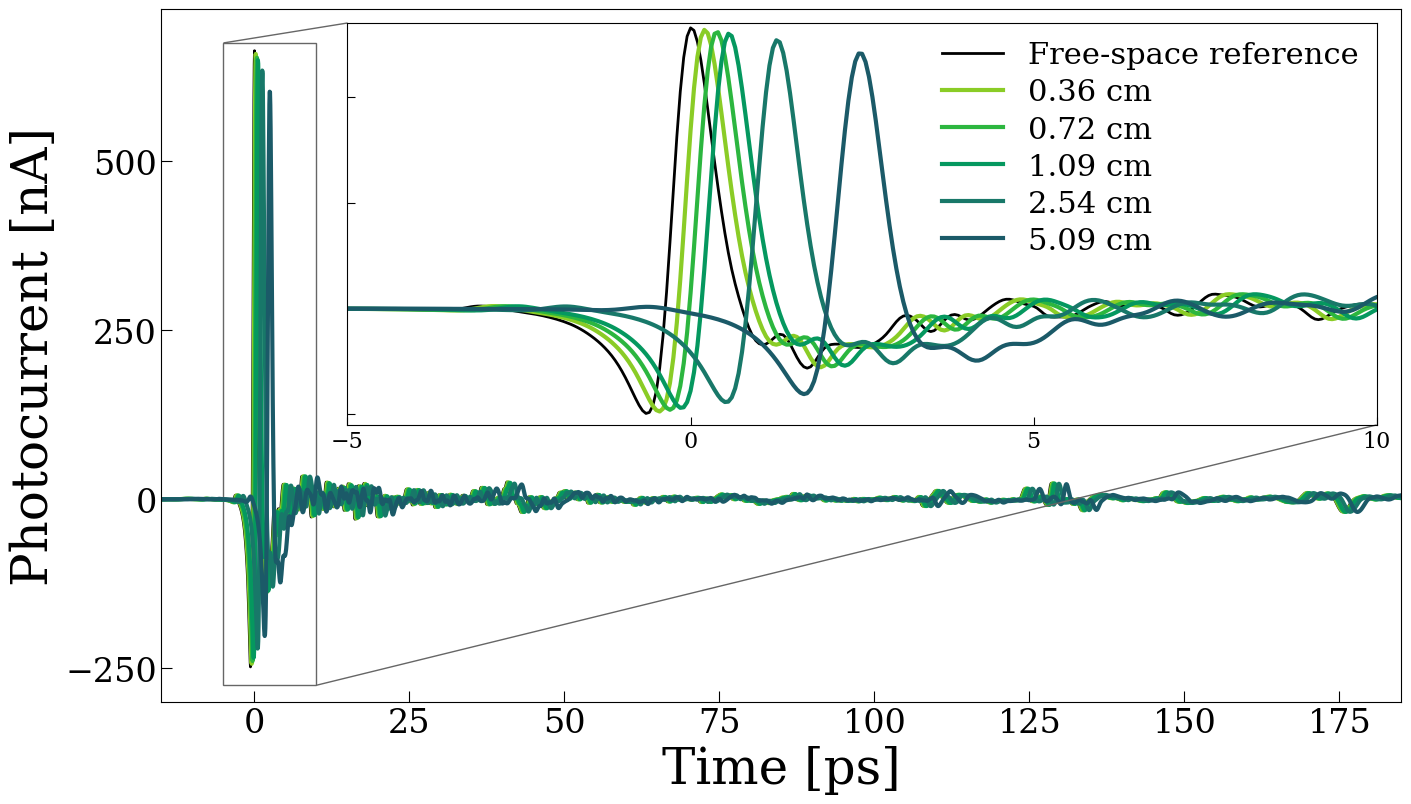

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(16, 9))

T_open,  pc_open  = site_25o4mm.get_base_pulse()

T0 = T_open[np.argmin(pc_open)]
t_ref = T_open - T0
y_ref = -pc_open

ax.set_xlim(-15, 185)

ylims = [-300, 725]
ax.set_ylim(ylims)
ax.set_yticks([-250, 0, 250, 500])
ax.xaxis.set_minor_locator(MultipleLocator(25))

ax.tick_params(axis="both", which='minor', size=4)
ax.tick_params(axis="both", which='major', size=8)

ax.set_xlabel("Time [ps]")
ax.set_ylabel("Photocurrent [nA]")

# ax.legend(frameon=False, loc="lower right", fontsize=22)

# inset
axins = inset_axes(ax, width="83%", height="58%", bbox_to_anchor=(0.15, 0.4, 1, 1), bbox_transform=ax.transAxes, loc="lower left", borderpad=0)

# plot references
ax.plot(t_ref, y_ref, color="k", lw=2, label="Free-space reference")
axins.plot(t_ref, y_ref, color="k", lw=2, label="Free-space reference")

# plot *all* samples in inset
for s in HD30_batch3.keys():
    width_cm = f"{HD30_batch3[s]['width']:.2f} cm"
    ax.plot(HD30_batch3[s]["T"] - T0, -HD30_batch3[s]["pc"], color=HD30_batch3[s]['color'], lw=3, label=width_cm)
    axins.plot(
        HD30_batch3[s]["T"] - T0,
        -HD30_batch3[s]["pc"],
        color=HD30_batch3[s]['color'],
        ls='-',
        lw=3,
        label=width_cm
    )

x1, x2 = -5, 10
axins.set_xlim(x1, x2)
axins.set_ylim([-275, 675])

axins.legend(frameon=False, loc="upper right", fontsize=22, handlelength=2.0, labelspacing=0.3, borderaxespad=0.2)

mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4", lw=1)

axins.set_xticks([-5, 0, 5, 10])
axins.set_yticks([-250, 0, 250, 500], labels=[])

axins.tick_params(axis="both", size=6, labelsize=16)

fig.patch.set_facecolor("white")
# plt.savefig("HD30_time_domain_inset.pdf", bbox_inches="tight", facecolor="white")
plt.show()

## Phase

In [78]:
# These samples have easily fixable phase jumps at high frequencies that are visually confusing to readers
bugged_batches = ['HD30 batch3 5.09 cm', 'LD15 batch2 0.30 cm', 'LD24 batch2 0.34 cm']
peak_nums = [1, 0, 0] # The index of the peak corresponding to bug

i = 0
for bname, b in batches.items():
    for sample in b:
        if bname == 'HD60 2.03 cm':
            phase_diff = np.unwrap(np.unwrap(b[sample]['theta']) - np.unwrap(b[sample]['theta_base']))
            while phase_diff[0] < 0:
                phase_diff += 2*np.pi
            while phase_diff[0] >= 2*np.pi:
                phase_diff -= 2*np.pi
            phase_diff -= phase_diff[0]
        else:
            phase_diff = b[sample]['theta'] - b[sample]['theta_base']
            while phase_diff[20] < 0:
                phase_diff += 2*np.pi
            while phase_diff[20] >= 2*np.pi:
                phase_diff -= 2*np.pi

        b[sample]['phase_diff'] = phase_diff

        if sample in bugged_batches: # Manually correct an easily fixable phase jump at 1719.6 GHz in this sample
            dtheta = np.diff(b[sample]['phase_diff'])
            Abs_dtheta = np.abs(dtheta)
            peaks, props = find_peaks(Abs_dtheta, height=0.5, distance=10)

            peak_num = peak_nums[i]
            idxs = np.arange(len(b[sample]['phase_diff'])) > peaks[peak_num]
            b[sample]['phase_diff'][idxs] += 2*np.pi
            i += 1
        

        b[sample]['delta_L'] = phase_diff*const.c/(2*np.pi*b[sample]['f']*1e9)
        b[sample]['n'] = 1 + b[sample]['delta_L']/b[sample]['width']*100 # convert to cm

        # Mask diffuse scatter regions in dense foams
        if bname == 'HD80 1" (25.8 mm)':
            ulim = 1390
        elif bname == 'HD110 0.8" (20.8 mm)':
            ulim = 545
        else:
            ulim = 2000

        freq_mask = (b[sample]['f'] <= ulim) # Can change if phase errors occur at high frequencies
        mask_n = freq_mask & (~b[sample]['mask'])

        b[sample]['n_masked'] = b[sample]['n'][mask_n]

        if sample == 'HD30 Batch1 2x1/8" (6.83 mm)':
            continue # Exclude this outlier sample from averaging
        
        b[sample]['n_eff'] = np.average(b[sample]['n_masked'], weights=b[sample]['t'][mask_n])
        b[sample]['n_eff_err'] = np.sqrt(np.average((b[sample]['n_masked'] - b[sample]['n_eff'])**2, weights=b[sample]['t'][mask_n]))

    valid = [sample for sample in b if sample != 'HD30 Batch1 2x1/8" (6.83 mm)']

    ## Each average is weighted by the inverse variance is the materials are homogenous.
    comb_batches[bname]['n_eff'] = np.average([b[sample]['n_eff'] for sample in valid], weights=[1/b[sample]['n_eff_err']**2 for sample in valid])
    
    propagated_err = np.sqrt(1 / np.sum([1/b[sample]['n_eff_err']**2 for sample in valid]))
    scatter_err = np.sqrt(np.average([(b[sample]['n_eff'] - comb_batches[bname]['n_eff'])**2 for sample in valid], weights=[1/b[sample]['n_eff_err']**2 for sample in valid]))
    comb_batches[bname]['n_eff_err'] = max(propagated_err, scatter_err)


## Evenly weight the batches within each material type
zote_neff2 = np.mean([comb_batches[sample]['n_eff'] for sample in comb_batches if sample in HD30_batches])
propagated_err = np.sqrt(np.sum([comb_batches[sample]['n_eff_err']**2 for sample in comb_batches if sample in HD30_batches])) / len(HD30_batches)
scatter_err = np.sqrt(np.mean([(comb_batches[sample]['n_eff'] - zote_neff2)**2 for sample in comb_batches if sample in HD30_batches]))
zote_neff2_err = max(propagated_err, scatter_err)

styro_neff2 = np.mean([comb_batches[sample]['n_eff'] for sample in comb_batches if sample in styro_batches])
propagated_err = np.sqrt(np.sum([comb_batches[sample]['n_eff_err']**2 for sample in comb_batches if sample in styro_batches])) / len(styro_batches)
scatter_err = np.sqrt(np.mean([(comb_batches[sample]['n_eff'] - styro_neff2)**2 for sample in comb_batches if sample in styro_batches]))
styro_neff2_err = max(propagated_err, scatter_err)

print(f"""
Zotefoams: n_eff = {zote_neff2:.3f} ± {zote_neff2_err:.3f}
Styrofoams: n_eff = {styro_neff2:.3f} ± {styro_neff2_err:.3f}
""")


Zotefoams: n_eff = 1.016 ± 0.002
Styrofoams: n_eff = 1.019 ± 0.002



C:\Users\Shreya Sutariya\AppData\Local\Temp\ipykernel_4832\629818212.py:35: RuntimeWarning: invalid value encountered in divide
  b[sample]['delta_L'] = phase_diff*const.c/(2*np.pi*b[sample]['f']*1e9)
C:\Users\Shreya Sutariya\AppData\Local\Temp\ipykernel_4832\629818212.py:35: RuntimeWarning: divide by zero encountered in divide
  b[sample]['delta_L'] = phase_diff*const.c/(2*np.pi*b[sample]['f']*1e9)


In [79]:
for bname, b in comb_batches.items():
    print(f"{bname}: n_eff = {b['n_eff']:.5f} ± {b['n_eff_err']:.2e}")

Styrofoam_batch: n_eff = 1.01885 ± 2.49e-03
LD15 batch1 2.65 cm: n_eff = 1.00893 ± 2.48e-05
LD15 batch2 0.30 cm: n_eff = 1.00878 ± 7.62e-05
LD24 batch1 2.60 cm: n_eff = 1.01153 ± 3.81e-05
LD24 batch2 0.34 cm: n_eff = 1.00956 ± 5.39e-05
HD30_batch1: n_eff = 1.01906 ± 2.66e-03
HD30_batch2: n_eff = 1.01392 ± 1.08e-03
HD30_batch3: n_eff = 1.01437 ± 4.32e-04
HD60 2.03 cm: n_eff = 1.02677 ± 4.23e-03
HD80 2.58 cm: n_eff = 1.03974 ± 4.82e-04
HD110 2.08 cm: n_eff = 1.06365 ± 8.99e-04


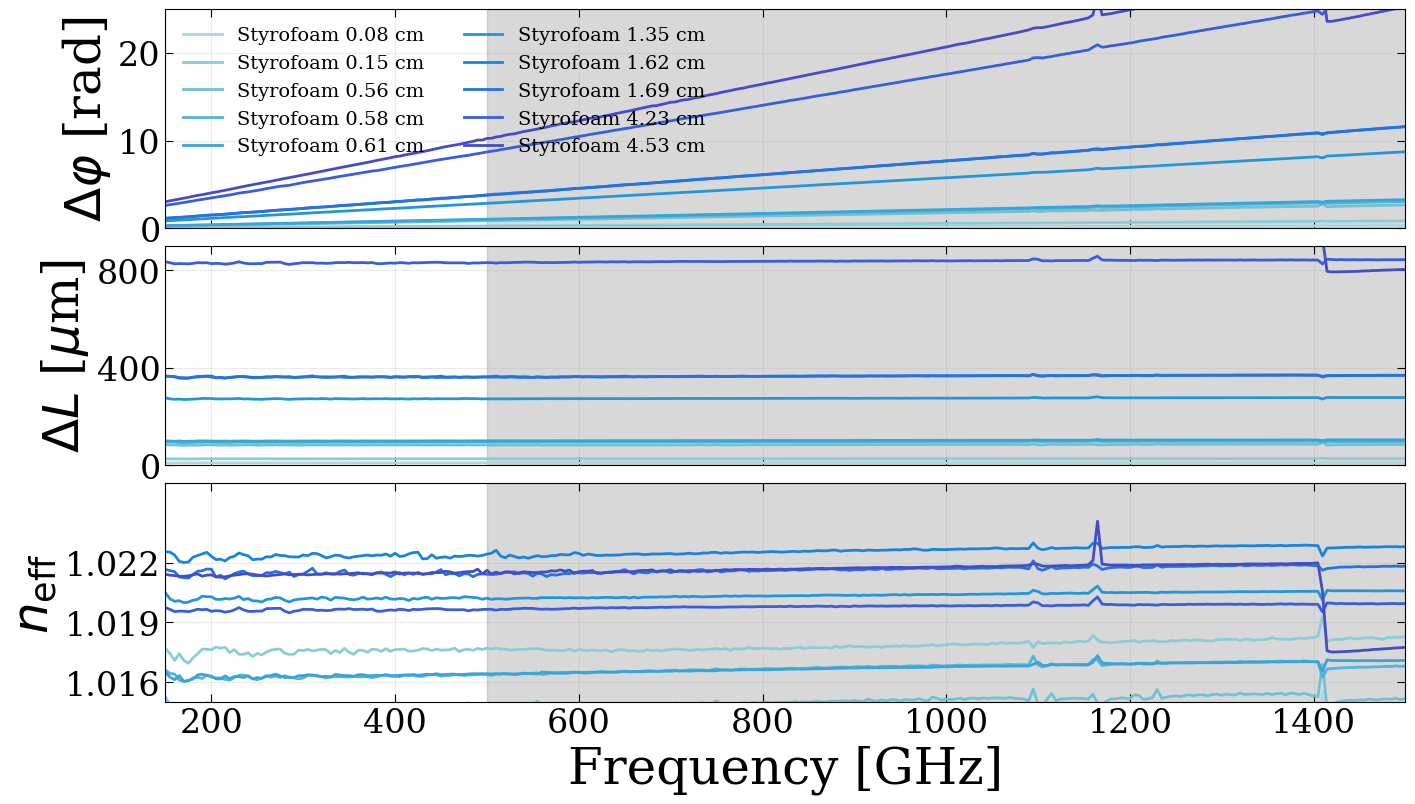

In [80]:
fig, axs = plt.subplots(
    3, 1, sharex=True, figsize=(16, 9),
    gridspec_kw=dict(height_ratios=[1, 1, 1], hspace=0.08)
)

for bname, b in batches.items():
    if "Styrofoam" not in bname:
        continue
    for sample in b:
        axs[0].plot(b[sample]['f'], b[sample]['phase_diff'], color=b[sample]['color'], lw=2, label=sample)
        axs[1].plot(b[sample]['f'], b[sample]['delta_L']*1e6, color=b[sample]['color'], lw=2, label=sample)
        axs[2].plot(b[sample]['f'], b[sample]['n'], lw=2, color=b[sample]['color'], label=sample)

# Axis labels
axs[0].set_ylabel(r'$\Delta \varphi$ [rad]')
axs[1].set_ylabel(r'$\Delta L$ [$\mu$m]')
axs[2].set_ylabel(r'$n_{\rm eff}$')
axs[2].set_xlabel('Frequency [GHz]')

# Limits / ticks
for ax in axs:
    for i, j in zip(mask_starts, mask_stops):
        ax.axvspan(i, j, color='gray', alpha=0.3)
    ax.set_xlim(150, 1500)
    # ax.set_xlim(0, 200)
    ax.grid(True, alpha=0.25)
    ax.tick_params(direction='in', length=6, top=True, right=True)

for i, j in zip(mask_starts, mask_stops):
    if ((i == 0) or (j >= 1500)):
        continue
    # else:
    #     axs[0].text((i+j)/2, 25, 'H$_2$O', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black', fontweight='bold')

axs[0].set_ylim(0, 25)
axs[1].set_ylim(0, 900)
axs[2].set_ylim(1.015, 1.026)
axs[1].set_yticks([0, 400, 800])
axs[2].set_yticks([1.016, 1.019, 1.022])
# Legend (single, clean)
axs[0].legend(loc='upper left', fontsize=14, edgecolor='k', frameon=False, ncol=2)

# Remove x tick labels on upper panels (sharex already, but makes it cleaner)
plt.subplots_adjust(hspace=0.08)
axs[0].label_outer()
axs[1].label_outer()
plt.show()


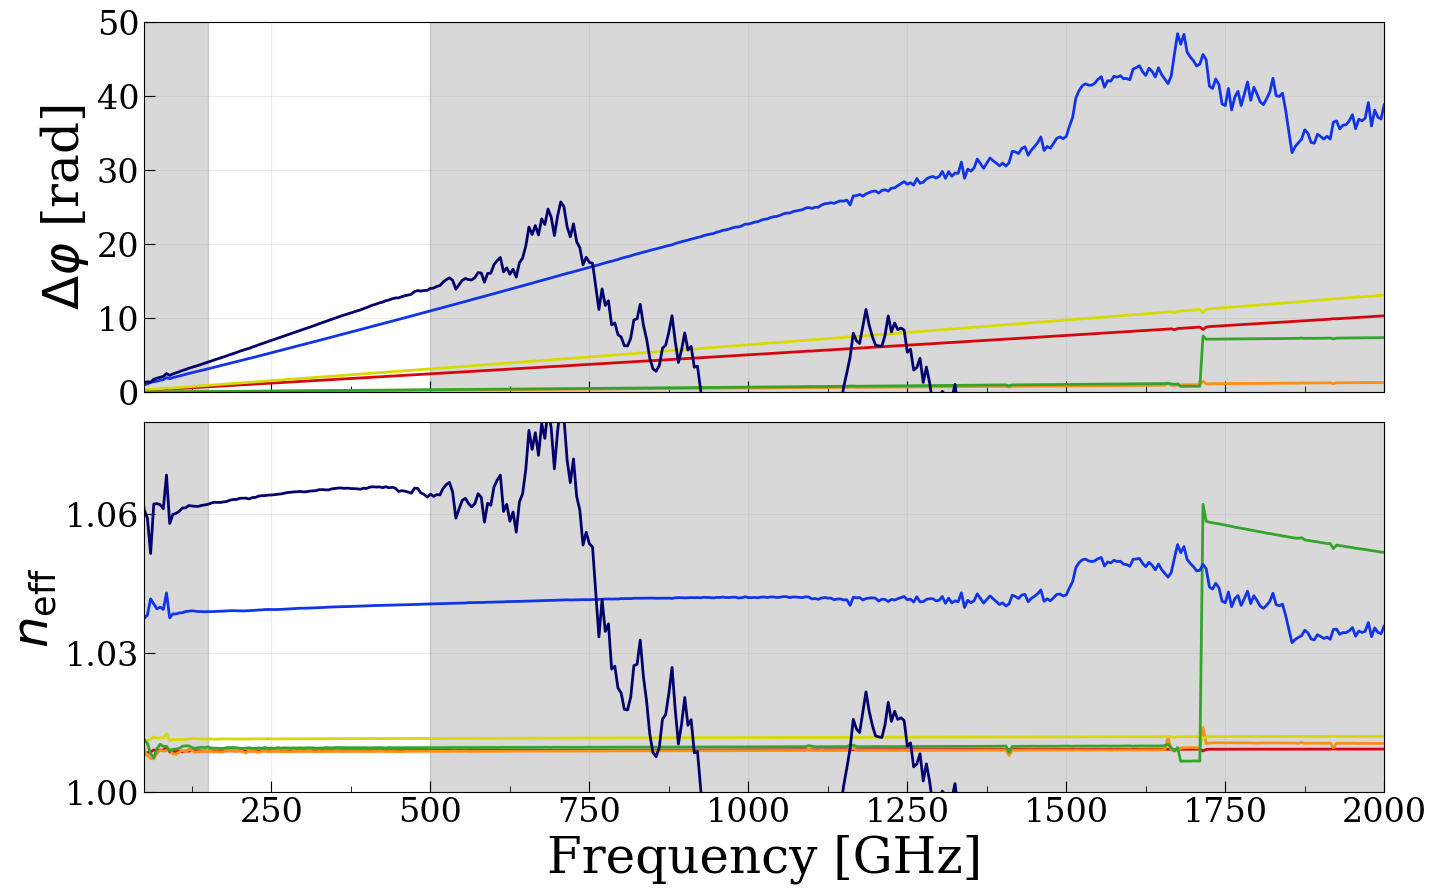

In [81]:
fig, axs = plt.subplots(
    2, 1, sharex=True, figsize=(16, 10),
    gridspec_kw=dict(height_ratios=[1, 1], hspace=0.08)
)

for bname, b in batches.items():
    if bname not in other_zote_keys or bname == 'HD60 2.03 cm':
        continue
    for sample in b:
        color = b[sample]['color']

        axs[0].plot(b[sample]['f'], b[sample]['phase_diff'],  color=color, lw=2, label=sample)
        axs[1].plot(b[sample]['f'], b[sample]['n'],           color=color, lw=2, label=sample)

# Axis labels
axs[0].set_ylabel(r'$\Delta \varphi$ [rad]')
axs[1].set_ylabel(r'$n_{\rm eff}$')
axs[1].set_xlabel('Frequency [GHz]')

# Limits / ticks
for ax in axs:
    for i, j in zip(mask_starts, mask_stops):
        ax.axvspan(i, j, color='gray', alpha=0.3)
    ax.set_xlim(50, 2000)
    # ax.set_xlim(0, 200)
    ax.grid(True, alpha=0.25)
axs[1].xaxis.set_major_locator(MultipleLocator(250))
axs[1].xaxis.set_minor_locator(MultipleLocator(125))

for i, j in zip(mask_starts, mask_stops):
    if ((i == 0) or (j >= 1500)):
        continue

axs[0].set_ylim(0, 50)
axs[1].set_ylim(1, 1.08)
axs[1].set_yticks([1, 1.03, 1.06])

# Remove x tick labels on upper panels (sharex already, but makes it cleaner)
plt.subplots_adjust(hspace=0.08)
axs[0].label_outer()
axs[1].label_outer()

plt.show()

## Frequency Domain

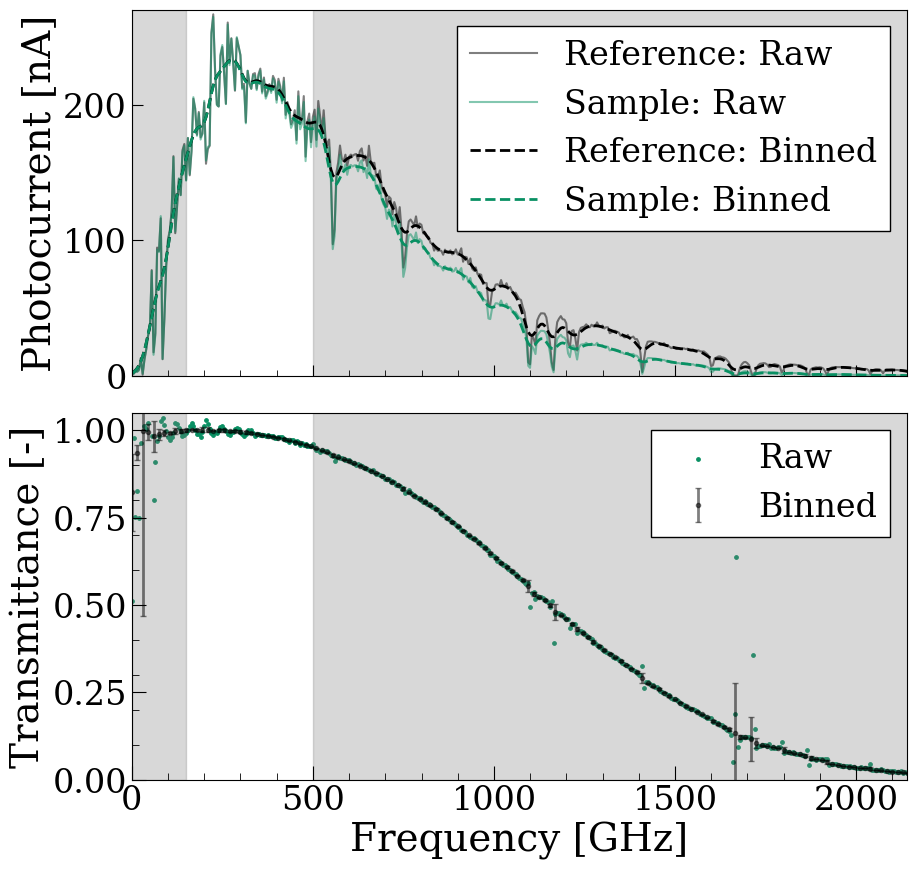

In [82]:
_, samp_amp = site_25o4mm.get_sample_current()
_, ref_amp  = site_25o4mm.get_base_current()

samp_amp_smoothed = getattr(site_25o4mm, 'bcsamp')
ref_amp_smoothed  = getattr(site_25o4mm, 'bcbase')
mes_err           = getattr(site_25o4mm, 'mes_err')

# Plot measurements and fits
sample = 'HD30 batch3 2.54 cm'
data = HD30_batch3[sample]

color = comb_batches["HD30_batch3"]['color']

fig, axs = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

ax0, ax1 = axs

ax0.plot(data['f'], ref_amp, color='k', alpha=0.5, label='Reference: Raw')
ax0.plot(data['f'], samp_amp, color=color, alpha=0.5, label='Sample: Raw')
ax0.plot(data['f'], ref_amp_smoothed, color='k', linestyle='--', linewidth=2, label='Reference: Binned')
ax0.plot(data['f'], samp_amp_smoothed, color=color, linestyle='--', linewidth=2, label='Sample: Binned')
# ax1.plot(data['f'], mes_err, color='cyan', linestyle='-', linewidth=2, label='Photon noise floor', zorder=10)

ax1.scatter(data['f'], data['ut'], color=color, s=6, label='Raw')
ax1.errorbar(data['f'][::data['boxnum']], data['t'][::data['boxnum']], yerr=data['err'][::data['boxnum']],
        fmt='o', markersize=3, linewidth=2, capsize=2, color='k', alpha=0.5, label='Binned')
    # plt.plot(data[sample]['f'], data[sample]['cf'], color='k', linestyle='--', linewidth=2, alpha=0.7, zorder=10, label=r'Rayleigh $\times$ Mie Model' if i == len(data)-1 else None)
data_handles, data_labels = plt.gca().get_legend_handles_labels()

xlims = (0, 2140)

for i, j in zip(mask_starts, mask_stops):
    for ax in axs:
        ax.axvspan(i, j, color='gray', alpha=0.3)
    if (i == 0):
        # ax0.text((xlims[0]+j)/2, 270, 'Instr.\nLimit', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black', fontweight='bold')
        continue
    elif (j == 10000):
        # ax0.text((i+xlims[1])/2, 270, 'Instr.\nLimit', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black', fontweight='bold')
        continue
    else:
        ax0.text((i+j)/2, 270, 'H$_2$O', horizontalalignment='center', verticalalignment='bottom', fontsize=12, color='black', fontweight='bold')


handles, labels = plt.gca().get_legend_handles_labels()
misc_handles = [handle for handle in handles if handle not in data_handles]
custom_line = [mpl.lines.Line2D([0], [1], color='lime', linestyle='--', label='Fitted data')]

# plt.legend(handles=data_handles + custom_line + misc_handles, edgecolor='black', fontsize=16, loc='upper right')
ax0.legend(fontsize=24, loc='upper right', framealpha=1, edgecolor='black', facecolor='white', fancybox=False)
ax1.legend(fontsize=24, loc='upper right', framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

ax1.set_xlim(xlims)
# ax0.set_yscale('log')
# ax1.set_yscale('log')
ax0.set_ylim(0, 270)
ax1.set_ylim(0, 1.05)
# ax1.set_ylim(1e-4, 1e0)
# ax1.set_ylim(0, 1.02)
ax1.yaxis.set_minor_locator(MultipleLocator(0.1))
ax0.xaxis.set_minor_locator(MultipleLocator(100))
plt.tick_params(axis='both', which='major', size=10)
plt.tick_params(axis='both', which='minor', size=5)
ax1.set_xlabel('Frequency [GHz]', fontsize=28)
ax0.set_ylabel('Photocurrent [nA]', fontsize=28)
ax1.set_ylabel('Transmittance [-]', fontsize=28)
plt.gcf().set_facecolor('white')
plt.subplots_adjust(hspace=0.1)

# plt.savefig('ut_vs_t_example.pdf', bbox_inches='tight', facecolor='white')
plt.show()

# Model functions

In [83]:
def IRBF_comp(f, params, width, n):
    lt, C, K_Ray, K_Mie = params
    Ray       = C*(f/K_Ray)**4
    Mie       = C*(2-4/(f/K_Mie)*np.sin(f/K_Mie)+4/(f/K_Mie)**2*(1-np.cos(f/K_Mie)))
    loss      = 2e7*np.pi*n*lt*f/const.c
    return np.exp(-width*loss), np.exp(-width*Ray), np.exp(-width*Mie)

def IRBF_components(f, params, width, n):
    lt, C, K_Ray, K_Mie = params
    Ray       = C*(f/K_Ray)**4
    Mie       = C*(2-4/(f/K_Mie)*np.sin(f/K_Mie)+4/(f/K_Mie)**2*(1-np.cos(f/K_Mie)))
    loss      = 2e7*np.pi*n*lt*f/const.c
    Abs_perc = 100*(1 - np.exp(-width*loss))
    Ray_perc  = 100*(1 - np.exp(-width*Ray))
    Mie_perc  = 100*(1 - np.exp(-width*Mie))
    return Abs_perc, Ray_perc, Mie_perc

def IRBF_abs(f, lt, width, n):
    loss      = 2e7*np.pi*n*lt*f/const.c
    Abs_perc = 100*(1 - np.exp(-width*loss))
    return Abs_perc

def chi2_dof(f, t, C, IRBF, len_params):
    chi2 = np.sum(((t - IRBF)/C)**2)
    dof  = len(f) - len_params
    return chi2/dof

Numba just in time (`njit`) version for efficient sampling

In [84]:
from numba import njit, prange

c = float(const.c)

@njit(fastmath=True)
def IRBF_njit(f, params, width, n):
    """
    f:      (Nf,) frequencies (GHz or whatever you're using; just be consistent)
    params: (4,)  [lt, C, K_Ray, K_Mie]
    width:  scalar sample width (cm)
    n:      scalar refractive index
    returns (Nf,)
    """
    lt, C, K_Ray, K_Mie = params

    # Rayleigh ~ C * (f / K_Ray)^4
    f2  = f * f
    f4  = f2 * f2
    KR4 = K_Ray**4
    Ray = C * f4 / KR4

    # Mie term: C * (2 - 4/(f / K_Mie) sin(f / K_Mie) + 4/(f / K_Mie)^2 (1 - cos(f / K_Mie)))
    f_over_k   = f / K_Mie
    sin_ = np.sin(f_over_k)
    cos_ = np.cos(f_over_k)
    inv  = 1.0 / (f_over_k)
    inv2 = inv * inv
    Mie  = C * (2.0 - 4.0 * (sin_ * inv) + 4.0 * ((1.0 - cos_) * inv2))

    # dielectric loss: 2e7 * pi * n * lt * f / c
    loss = (2.0e7 * np.pi * n * lt / c) * f

    return np.exp(-width*(loss + Ray + Mie))

@njit(fastmath=True)
def IRBF_alpha_njit(f, params, n):
    lt, C, K_Ray, K_Mie = params

    # Rayleigh ~ (f / K_Ray)^4
    f2  = f * f
    f4  = f2 * f2
    KR4 = K_Ray**4
    Ray = C * f4 / KR4

    # Mie term: C * (2 - 4/(f / K_Mie) sin(f / K_Mie) + 4/(f / K_Mie)^2 (1 - cos(f / K_Mie)))
    f_over_k   = f / K_Mie
    sin_ = np.sin(f_over_k)
    cos_ = np.cos(f_over_k)
    inv  = 1.0 / (f_over_k)
    inv2 = inv * inv
    Mie  = C * (2.0 - 4.0 * (sin_ * inv) + 4.0 * ((1.0 - cos_) * inv2))

    # dielectric loss: 2e7 * pi * n * lt * f / c
    loss = (2.0e7 * np.pi * n * lt / c) * f

    return loss + Ray + Mie

## Nested Sampling

In [85]:
#Nested Sampling
def transform_uniform(x, a, b):
    """The uniform prior transform function needed for dynesty."""
    return a + (b - a) * x

def transform_log10_uniform(x, a, b):
    return 10. ** (a + (b - a) * x)

def ptform(params, prior1, prior2, priortype):
    """Compute the prior transform for nested sampling."""
    p = np.zeros_like(params)
    for i in range(len(params)):
        if priortype[i] == 'U':
            p[i] = transform_uniform(params[i], prior1[i], prior2[i])
        elif priortype[i] == 'LU':
            p[i] = transform_log10_uniform(params[i], prior1[i], prior2[i])
        else:
            raise ValueError("PriorType must be 'U' or 'LU'")
    return p

def loglike(params, f, t, width, err, n_eff):
    model = IRBF_njit(f, params, width, n_eff)
    loglike = -0.5 * np.sum((t - model)**2 / err**2 + np.log(2 * np.pi * err**2))
    return loglike

def fitting(f, t, width, err, n_eff):
    prior1 = [-10, -5, 100,  100]
    prior2 = [-3, 2, 4000, 4000]
    priortype = ["LU", "LU", "U", "U"]
    loglike_args = [f, t, width, err, n_eff]

    print('Running Nested Sampling...')
    sampler = dynesty.NestedSampler(loglike, ptform, ndim=4, nlive=nlive, bound='multi', sample='rslice', logl_args = loglike_args, ptform_args = [prior1, prior2, priortype])
    sampler.run_nested(dlogz=dlogz, print_progress=True)

    return sampler.results

############# Configure below the line to adjust the nested sampling #############
nlive = 10000 
dlogz = 0.01

## Batch Fits

In [86]:
for bname, b in comb_batches.items():
    bname_cleaned = bname.replace(" ", "_").replace('"', 'in')
    fpath = f'pkls/{bname_cleaned}_model_500GHz.pkl'

    if os.path.exists(fpath):
        with open(fpath, 'rb') as file:
            results = pickle.load(file)
            if results.nlive >= nlive:
                b['weights'] = np.exp(results['logwt'] - results['logz'][-1])
                b['samples'] = dynesty.utils.resample_equal(results.samples, b['weights'])
                print(f'Number of posterior {bname} samples:', len(b['samples']))
                continue

    f_    = b['f_comb']
    t     = b['t_comb']
    width = b['width_comb']
    err   = b['err_comb']
    n_eff = b['n_eff']
    results = fitting(f_, t, width, err, n_eff)

    results.summary()

    b['weights'] = np.exp(results['logwt'] - results['logz'][-1])
    b['samples'] = dynesty.utils.resample_equal(results.samples, b['weights'])
    print(f'Number of posterior {bname} samples:', len(b['samples']))

    # Save the results
    with open(fpath, 'wb') as file:
        pickle.dump(results, file)

Number of posterior Styrofoam_batch samples: 257719
Number of posterior LD15 batch1 2.65 cm samples: 240196
Number of posterior LD15 batch2 0.30 cm samples: 201860
Number of posterior LD24 batch1 2.60 cm samples: 158692
Number of posterior LD24 batch2 0.34 cm samples: 119544
Number of posterior HD30_batch1 samples: 184045
Number of posterior HD30_batch2 samples: 168200
Number of posterior HD30_batch3 samples: 170685
Number of posterior HD60 2.03 cm samples: 109444
Number of posterior HD80 2.58 cm samples: 192375
Number of posterior HD110 2.08 cm samples: 202154


In [87]:
@njit(parallel=True, fastmath=True)
def IRBF_batch_params(f, samples, width, n):
    Ns = samples.shape[0]
    Nf = f.size
    out = np.empty((Ns, Nf), dtype=np.float64)
    for i in prange(Ns):
        out[i, :] = IRBF_njit(f, samples[i, :], width, n)
    return out

@njit(parallel=True, fastmath=True)
def alpha_batch_params(f, samples, n):
    Ns = samples.shape[0]
    Nf = f.size
    out = np.empty((Ns, Nf), dtype=np.float64)
    for i in prange(Ns):
        out[i, :] = IRBF_alpha_njit(f, samples[i, :], n)
    return out

alphas = {}

for bname, b in comb_batches.items():
    bname_cleaned = bname.replace(" ", "_").replace('"', 'in')
    fpath = f'pkls/{bname_cleaned}_alpha_500GHz.pkl'
    if os.path.exists(fpath):
        with open(fpath, 'rb') as file:
            b['alpha_lower'], b['ns_alpha'], b['alpha_upper'] = pickle.load(file)
    else:
        alpha = alpha_batch_params(f, b['samples'], b['n_eff'])
        b['alpha_lower'], b['ns_alpha'], b['alpha_upper'] = np.percentile(alpha, [16, 50, 84], axis=0)
        with open(fpath, 'wb') as file:
            pickle.dump((b['alpha_lower'], b['ns_alpha'], b['alpha_upper']), file)

In [88]:
w = 5 # 5 cm assembly example

for bname, b in comb_batches.items():
    q = np.percentile(b['samples'], [16, 50, 84], axis=0)

    b['params']    = q[1]
    b['upper_params'] = q[2] - q[1]
    b['lower_params'] = q[1] - q[0]
    b['C_params'] = (q[2] - q[0])/2
    b[f'T_upper_5cm'], b[f'ns_T_5cm'], b[f'T_lower_5cm'] = np.exp(-w*b['alpha_lower']), np.exp(-w*b['ns_alpha']), np.exp(-w*b['alpha_upper'])

    n_eff = b['n_eff']

    for sample_name, sample in batches[bname].items():
        ## transform samples from parameter space to transmission
        width = sample['width']
        sample['T_upper'], sample['ns_T'], sample['T_lower'] = np.exp(-width*b['alpha_lower']), np.exp(-width*b['ns_alpha']), np.exp(-width*b['alpha_upper'])
        diff = sample['T_upper'] - sample['T_lower']

## Combined Sampling Results

In [89]:
def round_uncertainty(x):
    """Return (rounded_value, decimal_places_for_round())."""
    x = float(x)
    if x == 0.0:
        return 0.0, 0

    exponent = int(np.floor(np.log10(abs(x))))

    # first_digit = abs(x) / 10**exponent
    # sigfigs = 2 if first_digit < 1.95 else 1
    sigfigs = 1
    
    decimals = int(sigfigs - 1 - exponent)  # can be negative!

    return round(x, decimals), decimals

def sci_scale(x):
    """
    Return (scaled_x, exponent) such that:
    x = scaled_x * 10**exponent
    """
    if x == 0:
        return 0.0, 0
    exponent = int(np.floor(np.log10(abs(x))))
    return x / 10**exponent, exponent

def format_unc(mu, C_minus, C_plus, sci_thresh=1e-3):
    mu = float(mu)
    C_minus = float(C_minus)
    C_plus  = float(C_plus)

    use_sci = abs(mu) < sci_thresh and mu != 0

    if use_sci:
        mu_s, exp = sci_scale(mu)
        sm_s = C_minus / 10**exp
        sp_s = C_plus  / 10**exp
    else:
        mu_s, sm_s, sp_s = mu, C_minus, C_plus
        exp = None

    # Determine rounding from uncertainties
    _, d1 = round_uncertainty(sm_s)
    _, d2 = round_uncertainty(sp_s)
    decimals = max(d1, d2)

    mu_r = round(mu_s, decimals)
    sm_r = round(sm_s, decimals)
    sp_r = round(sp_s, decimals)

    prec = max(decimals, 0)
    fmt = f"{{:.{prec}f}}"

    core = rf"{fmt.format(mu_r)}^{{+{fmt.format(sp_r)}}}_{{-{fmt.format(sm_r)}}}"

    if use_sci:
        return rf"${core}\times10^{{{exp}}}$"
    else:
        return rf"${core}$"
    
def format_unc_1sided(mu, C, sci_thresh=1e-3, shorthand=True):
    mu = float(mu)
    C = float(C)

    use_sci = abs(mu) < sci_thresh and mu != 0

    if use_sci:
        mu_s, exp = sci_scale(mu)
        C_s = C / 10**exp
    else:
        mu_s, C_s = mu, C
        exp = None

    _, decimals = round_uncertainty(C_s)
    mu_r = round(mu_s, decimals)
    C_r = round(C_s, decimals)

    prec = max(decimals, 0)
    fmt = f"{{:.{prec}f}}"

    if shorthand and not use_sci:
        ### e.g. 1.013(1) for 1.013 ± 0.001
        C_int = round(C_r * 10**prec)
        core = rf"{fmt.format(mu_r)}({C_int})"
        return rf"${core}$"

    core = rf"{fmt.format(mu_r)} \pm {fmt.format(C_r)}"

    if use_sci:
        return rf"${core}\times10^{{{exp}}}$"
    else:
        return rf"${core}$"
    
def format_val(val, sci_thresh=1e-2):
    val = float(val)
    
    use_sci = abs(val) < sci_thresh and val != 0

    if use_sci:
        exp = int(np.floor(np.log10(abs(val))))
        core = val / 10**exp
        return rf"${core:.1f}\times10^{{{exp}}}$"
    else: 
        return rf"${val:.2f}$"


def get_corner_handles(bs, type=None):
    handles = []
    
    for b in bs:
        if type == None:
            sample_cleaned = b.replace('_', ' ')
        elif type == 'HD30':
            sample_cleaned = b.replace('_', ' ').replace('HD30 ', '').replace('batch', 'Batch ')
        elif type == 'Styrofoam':
            sample_cleaned = b.replace('_', ' ').replace('Styrofoam', '').replace('batch', 'Batch ')
        else:
            raise ValueError("type must be None, 'HD30', or 'Styrofoam'")
        base = comb_batches[b]['color']

        # Convert to RGBA and make a lighter facecolor (blend with white)
        r, g, b, a = mcolors.to_rgba(base)
        light = (0.5 + 0.5*r, 0.5 + 0.5*g, 0.5 + 0.5*b, 0.9)
        dark  = (r, g, b, 1.0)                             

        # Zero-size Rectangle proxy like anesthetic (width/height don't matter for legend)
        patch = mpatches.Rectangle(
            (0, 0), 0, 0,
            facecolor=dark,
            edgecolor=light,
            linewidth=4,
            label=sample_cleaned,
        )
        handles.append(patch)

    return handles

Get band averages from the estimates

In [90]:
def f_m_from_rho(rho_eff, rho_m, rho_c=1.25):
    """Matrix volume fraction from density mixing: rho_eff = f_m rho_m + (1-f_m) rho_c."""
    return (rho_eff - rho_c) / (rho_m - rho_c)

def lt_eff(f_m, tan_delta_m, n_m, n_eff, n_c=1.0003):
    """
    Maxwell–Garnett (dilute polymer inclusions in gas host) effective loss tangent.

    tanδ_eff = [9 f_m n_c^4 n_m^2 / (n_m^2 + 2 n_c^2)^2] * (1 / n_eff^2) * tanδ_m
    """
    num = 9.0 * f_m * (n_c**4) * (n_m**2)
    den = (n_m**2 + 2.0 * n_c**2)**2
    return (num / den) * (1.0 / (n_eff**2)) * tan_delta_m

for bname, b in comb_batches.items():

    ## Estimate the loss tangent
    if "HD" in bname:
        density = b['density']

        rho_m = 950
        lt_m = 2.5e-4 # HDPE loss tangent from literature
        n_m = 1.54

        
    elif "LD" in bname:
        density = b['density']

        rho_m = 925
        lt_m  = 2.7e-4 # Using the HDPE estimate which should be quite close
        n_m   = 1.514   # Literature estimates this value as slightly lower...
    elif "Styrofoam" in bname:
        rho_m = 1050
        lt_m = 6.9e-3 # Polystyrene loss tangent from literature
        n_m   = 1.59
    else:
        raise ValueError(f"Unknown material type: {bname}")

    density = b['density']
    f_m = f_m_from_rho(density, rho_m)
    b['f_m'] = f_m
    b['lt'] = lt_eff(f_m, lt_m, n_m, b['n_eff'])

In [91]:
band_windows_full = {
    "30":  (24, 30),
    "40":  (30, 47),
    "90":  (75, 110),
    "150": (120, 165),
    "220": (195, 255),
    "280": (260, 305),
    "350": (330, 370),
}

for bname, b in comb_batches.items():
    ## Constrain the components
    params       = b["params"]
    upper_params = b["upper_params"]
    lower_params = b["lower_params"]
    n_eff        = b["n_eff"]
    lt           = b["lt"]

    Abs,       Ray,       Mie,      = IRBF_components(f, params, w, n_eff)
    Abs_upper, Ray_upper, Mie_upper = IRBF_components(f, params + upper_params, w, n_eff)
    Abs_lower, Ray_lower, Mie_lower = IRBF_components(f, params - lower_params, w, n_eff)

    Abs_lower = np.zeros_like(Abs_lower)
    Abs = IRBF_abs(f, lt, w, n_eff)
    Abs_upper = 2*Abs

    estimates = {
        "Abs": dict(arr=Abs, upper=Abs_upper, lower=Abs_lower, color='tab:red',    ls='-'),
        "Ray":  dict(arr=Ray,  upper=Ray_upper,  lower=Ray_lower,  color='tab:blue',   ls='--'),
        "Mie":  dict(arr=Mie,  upper=Mie_upper,  lower=Mie_lower,  color='tab:orange', ls=':'),
    }

    b["estimates"] = estimates

    band_avgs = {}
    for band, (lo_f, hi_f) in band_windows_full.items():
        sel = (f > lo_f) & (f < hi_f)
        
        for comp, est_data in estimates.items():
            val       = np.mean(est_data['arr'][sel])
            upper_val = np.mean(est_data['upper'][sel])
            lower_val = np.mean(est_data['lower'][sel])

            up = upper_val - val
            lo = val - lower_val

            band_avgs[(band, comp)]            = val
            band_avgs[(band, f"{comp}_upper")] = up
            band_avgs[(band, f"{comp}_lower")] = lo

    b["band_avgs"] = band_avgs

    ## Band averaged transmission with uncertainties
    T_lower, ns_T, T_upper = b['T_lower_5cm'], b['ns_T_5cm'], b['T_upper_5cm']
    for band_name, (lo_f, hi_f) in band_windows_full.items():
        sel = (f > lo_f) & (f < hi_f)
        val = float(np.mean(ns_T[sel]))
        upper_val = float(np.mean(T_upper[sel]))
        lower_val = float(np.mean(T_lower[sel]))

        up = upper_val - val
        lo = val - lower_val

        b[f"T{band_name}"] = format_unc(val, lo, up)

# Fixed Loss tangent fitting

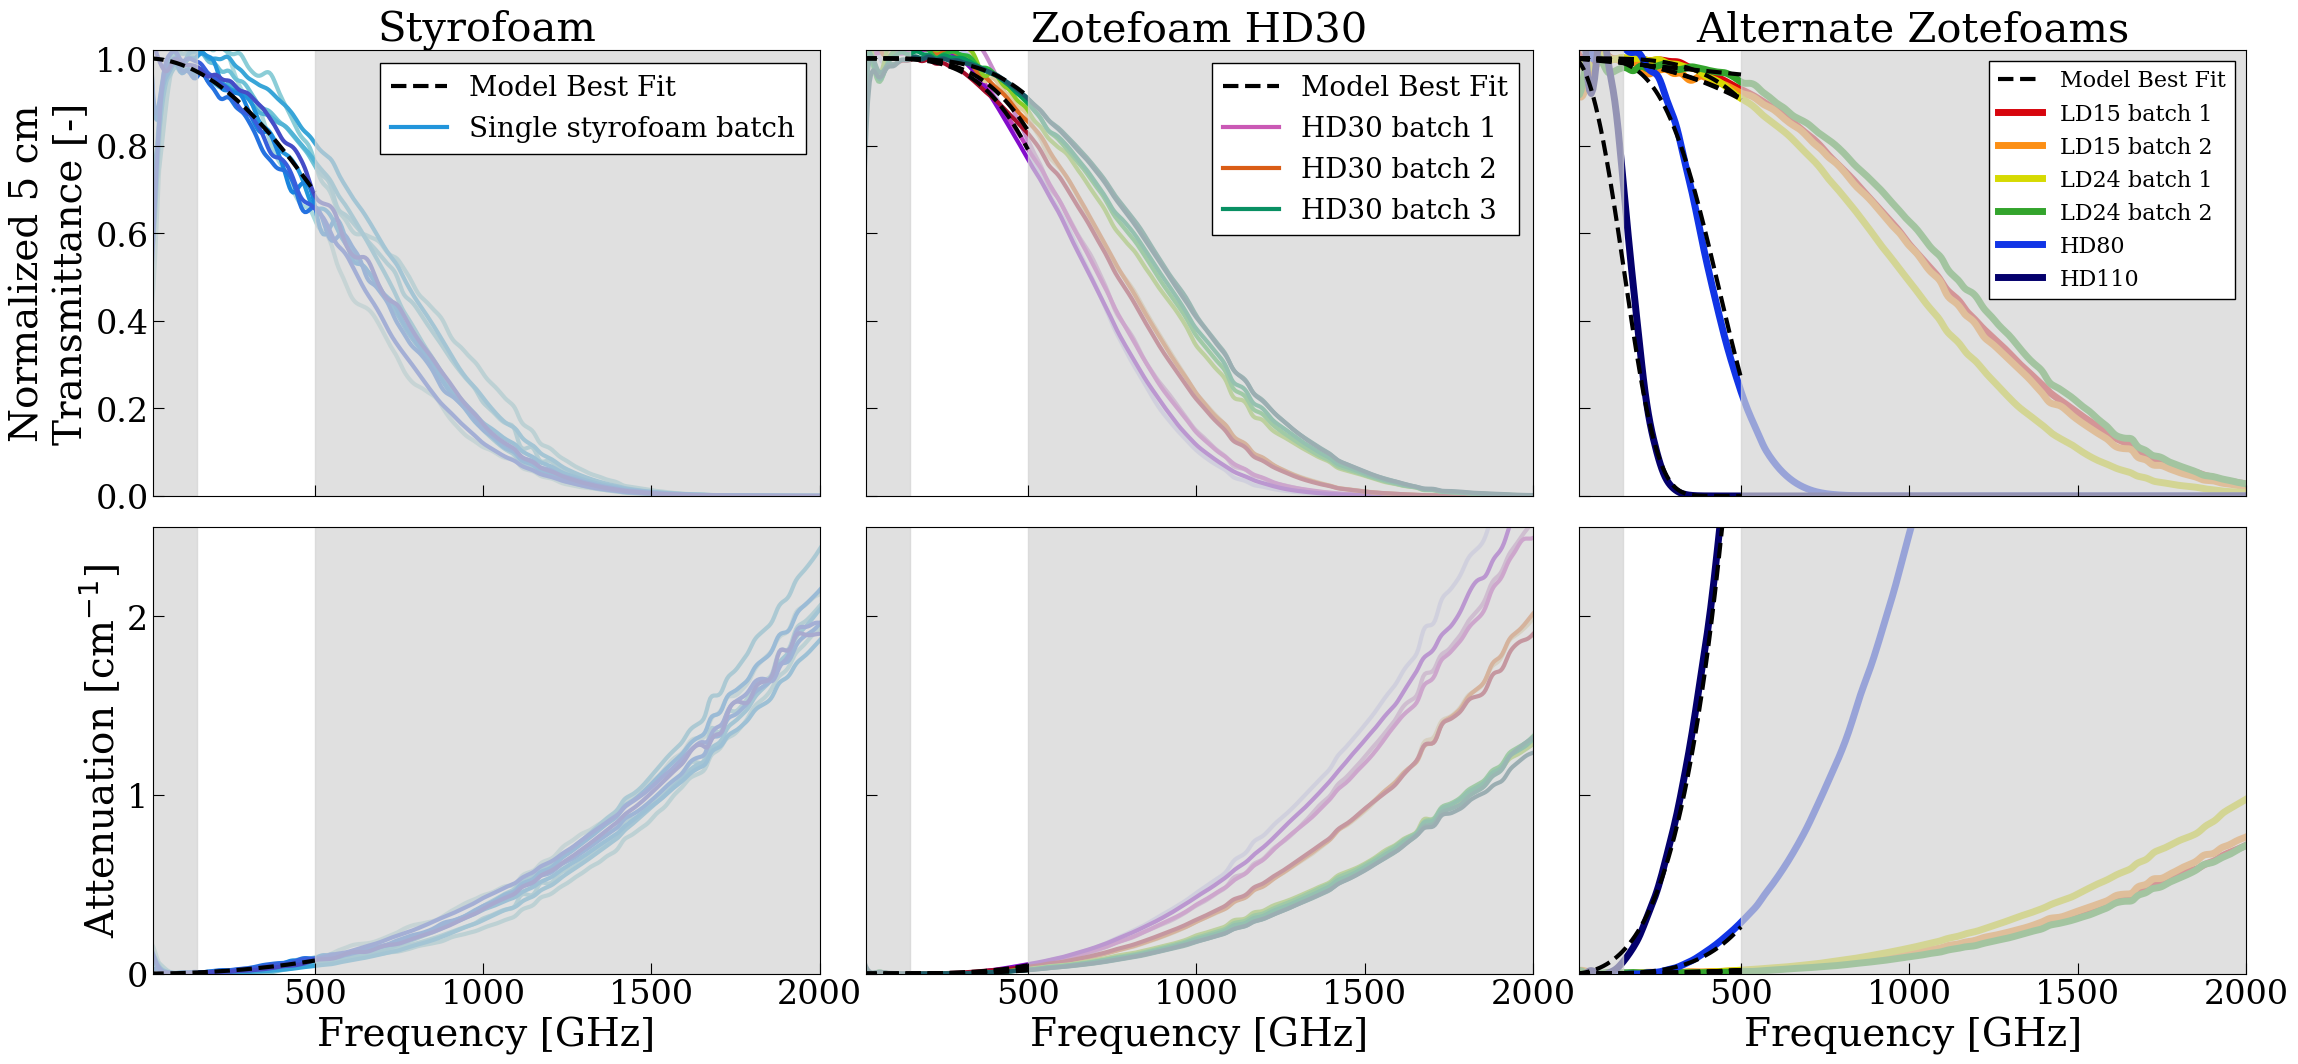

In [92]:
fig, axes = plt.subplots(2, 3, figsize=(27, 12), sharex=True, sharey='row')

plt.xlim(20, 2000)
axes[0, 0].set_ylim(0, 1.02)
axes[1, 0].set_ylim(0, 2.5)
axes[0, 0].set_ylabel('Normalized 5 cm\nTransmittance [-]', fontsize=28)
axes[1, 0].set_ylabel(r'Attenuation [cm$^{-1}$]', fontsize=28)

for ax in axes[1, :]:
    ax.set_xlabel('Frequency [GHz]', fontsize=28)

for bname, b in batches.items():
    i = 0
    if bname in styro_batches:
        ax1 = axes[0, 0]
        ax2 = axes[1, 0]
        lw = 3
    elif bname in HD30_batches:
        ax1 = axes[0, 1]
        ax2 = axes[1, 1]
        lw = 3
    elif bname in other_zote_keys and bname != 'HD60 2.03 cm':
        ax1 = axes[0, 2]
        ax2 = axes[1, 2]
        lw = 5
    else:
        continue

    for j, sample in enumerate(b):
        if ax == ax2:
            sample_cleaned = DISPLAY_MAP[sample]
            width = b[sample]['width']
            label = sample_cleaned
        else:
            label = sample.split(' ', 1)[1].replace('batch', 'Batch ').replace('combined', 'comb.')
        
        f_    = b[sample]['f']
        t     = b[sample]['t']
        alpha = b[sample]['alpha']
        err   = b[sample]['err']
        color = b[sample]['color']

        ns_T = b[sample]['ns_T']
        ns_alpha = comb_batches[bname]['ns_alpha']
        width = b[sample]['width']
        ns_T_5cm = ns_T**(5/width)
        


        ax1.plot(f_, t**(5/width), color=color, lw=lw, label=label, zorder=-10)
        ax2.plot(f_, alpha, color=color, lw=lw, label=label, zorder=-10)

        # transform to display coordinates

        if i == 0:
            ax2.plot(f, ns_alpha, color='k', linestyle='--', lw=3, zorder=10)
            ax1.plot(f, ns_T_5cm, color='k', linestyle='--', lw=3, zorder=10)

        i += 1


for ax in axes.flatten():
    for i, j in zip(mask_starts, mask_stops):
        ax.axvspan(i, j, color='lightgray', alpha=0.7)

custom_line = mpl.lines.Line2D([0], [1], color='k', linestyle='--', lw=3, label='Model Best Fit')

styro_line  = mpl.lines.Line2D([0], [1], color=comb_batches['Styrofoam_batch']['color'], lw=3, label='Single styrofoam batch')

hd30_line1 = mpl.lines.Line2D([0], [1], color=comb_batches['HD30_batch1']['color'], lw=3, label='HD30 batch 1')
hd30_line2 = mpl.lines.Line2D([0], [1], color=comb_batches['HD30_batch2']['color'], lw=3, label='HD30 batch 2')
hd30_line3 = mpl.lines.Line2D([0], [1], color=comb_batches['HD30_batch3']['color'], lw=3, label='HD30 batch 3')

handles = [custom_line, styro_line]

axes[0, 0].legend(handles=handles, loc='upper right', fontsize=20, framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

handles = [custom_line, hd30_line1, hd30_line2, hd30_line3]
axes[0, 1].legend(handles=handles, loc='upper right', fontsize=20, framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

handles = axes[0, 2].get_legend_handles_labels()[0]
handles.insert(0, custom_line)
axes[0, 2].legend(handles=handles, loc='upper right', fontsize=16, framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

axes[0, 0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
axes[1, 0].set_yticks([0, 1, 2])
axes[0, 0].set_title('Styrofoam', fontsize=30)
axes[0, 1].set_title('Zotefoam HD30', fontsize=30)
axes[0, 2].set_title('Alternate Zotefoams', fontsize=30)

plt.gcf().set_facecolor('white')
plt.subplots_adjust(wspace=0.07, hspace=0.07)
# plt.savefig('spectras.pdf', bbox_inches='tight', facecolor='white')
plt.show()

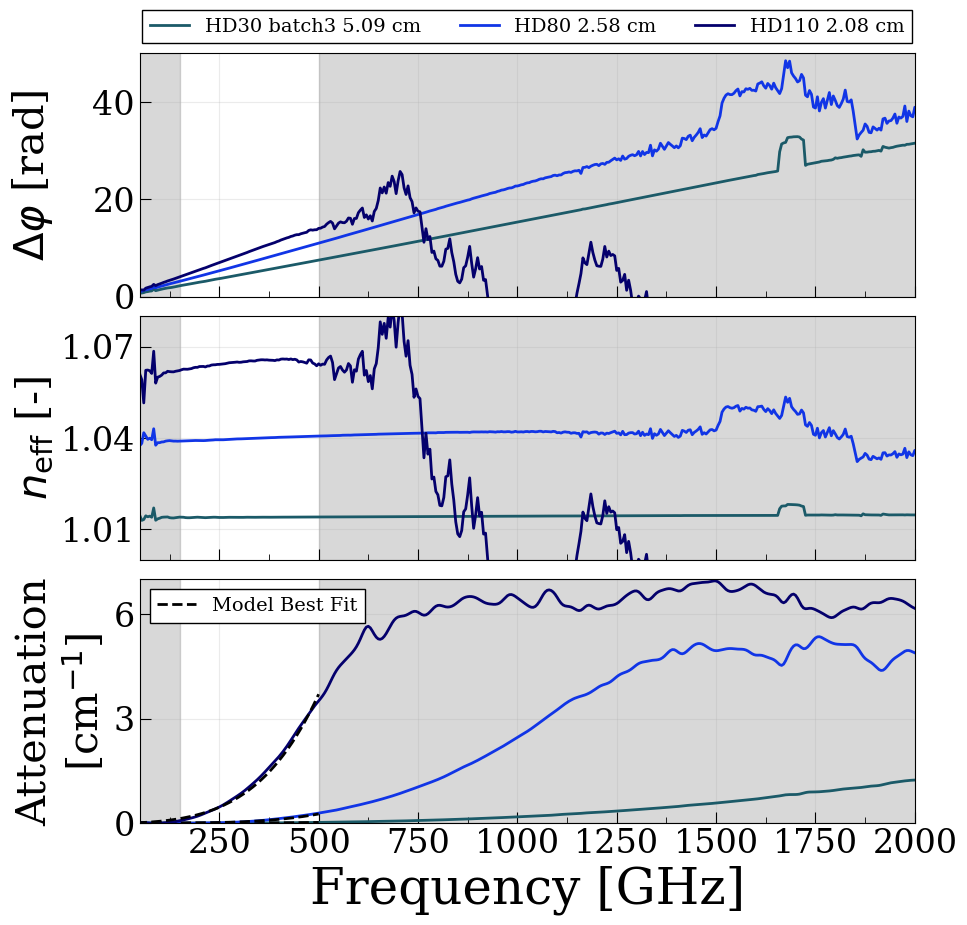

In [93]:
fig, axs = plt.subplots(
    3, 1, sharex=True, figsize=(10, 10),
    gridspec_kw=dict(height_ratios=[1, 1, 1], hspace=0.08)
)

i = 0
for bname, b in batches.items():
    for sample in b:
        if bname not in ['HD80 2.58 cm', 'HD110 2.08 cm'] and sample != 'HD30 batch3 5.09 cm':
            continue

        color = b[sample]['color']

        axs[0].plot(f_, b[sample]['phase_diff'],  color=color, lw=2)
        axs[1].plot(f_, b[sample]['n'],           color=color, lw=2)
        axs[2].plot(f_, b[sample]['alpha'],       color=color, lw=2, label=sample)
        axs[2].plot(f, comb_batches[bname]['ns_alpha'], color='k', linestyle='--', lw=2)
        i += 1

# Axis labels
axs[0].set_ylabel(r'$\Delta \varphi$ [rad]', fontsize=30)
axs[1].set_ylabel(r'$n_{\rm eff}$ [-]', fontsize=30)
axs[2].set_ylabel(f'Attenuation\n'+r'[cm$^{-1}$]', fontsize=30)
axs[2].set_xlabel('Frequency [GHz]')

# Limits / ticks
for ax in axs:
    for i, j in zip(mask_starts, mask_stops):
        ax.axvspan(i, j, color='gray', alpha=0.3)
    ax.set_xlim(50, 2000)
    # ax.set_xlim(0, 200)
    ax.grid(True, alpha=0.25)
axs[1].xaxis.set_major_locator(MultipleLocator(250))
axs[1].xaxis.set_minor_locator(MultipleLocator(125))

for i, j in zip(mask_starts, mask_stops):
    if ((i == 0) or (j >= 1500)):
        continue

style_handles = [Line2D([0], [0], color='k', lw=2, linestyle='--', label='Model Best Fit')]

axs[0].set_ylim(0, 50)
axs[1].set_ylim(1, 1.08)
axs[1].set_yticks([1.01, 1.04, 1.07])
axs[2].set_ylim(0, 7)
axs[2].set_yticks([0, 3, 6])
# Legend (single, clean)

handles, labels = axs[2].get_legend_handles_labels()

axs[0].legend(handles, labels, fontsize=14, loc='lower center', 
               bbox_to_anchor=(0.5, 1), ncol=3, framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

axs[2].legend(handles=style_handles, fontsize=14, loc='upper left', framealpha=1, edgecolor='black', facecolor='white', fancybox=False)

# Remove x tick labels on upper panels (sharex already, but makes it cleaner)
plt.subplots_adjust(hspace=0.08)
axs[0].label_outer()
axs[1].label_outer()

fig.align_ylabels([axs[0], axs[1]])
# plt.savefig("phase_plot-d.pdf", bbox_inches='tight', facecolor='white')
plt.show()

In [94]:
rows = []

param_names = ["Loss tangent", "C", "K_ray", "K_Mie"]

for bname, b in comb_batches.items():
    if 'HD60' in bname:
        continue
    row = {"Sample": DISPLAY_MAP[bname]}

    # Get the parameters and uncertainties from the appropriate fit

    for i, pname in enumerate(param_names):
        val = float(b['params'][i])
        up  = float(b['upper_params'][i])
        lo  = float(b['lower_params'][i])

        if pname == 'Loss tangent':
                row[pname] = format_val(val+up)
        else:
            row[pname] = format_unc(val, lo, up)

    val = b['n_eff']
    sig = b['n_eff_err']

    row["n_eff^2"] = format_unc_1sided(val, sig)

    rows.append(row)

df = pd.DataFrame(rows)

for _, row in df.iterrows():
    cells = [row["Sample"]] + [row[p] for p in param_names] + [row["n_eff^2"]]
    print(" & ".join(cells) + r" \\")

Styrofoam batch & $6.5\times10^{-9}$ & $7.7^{+0.8}_{-1.1}$ & $3170^{+80}_{-130}$ & $3700^{+200}_{-300}$ & $1.019(2)$ \\
LD15 batch 1 & $3.2\times10^{-9}$ & $1.8^{+0.3}_{-0.4}$ & $2700^{+100}_{-200}$ & $3600^{+300}_{-500}$ & $1.00893(2)$ \\
LD15 batch 2 & $6.2\times10^{-8}$ & $1.2^{+0.7}_{-0.6}$ & $2400^{+300}_{-400}$ & $3000^{+700}_{-800}$ & $1.00878(8)$ \\
LD24 batch 1 & $1.6\times10^{-7}$ & $0.001^{+0.007}_{-0.001}$ & $200^{+200}_{-100}$ & $2600^{+900}_{-1200}$ & $1.01153(4)$ \\
LD24 batch 2 & $7.2\times10^{-5}$ & $8^{+195}_{-8}\times10^{-4}$ & $2000^{+1000}_{-1000}$ & $2000^{+1000}_{-1000}$ & $1.00956(5)$ \\
HD30 batch 1 & $1.6\times10^{-8}$ & $3^{+7}_{-2}\times10^{-4}$ & $140^{+50}_{-30}$ & $3000^{+700}_{-1000}$ & $1.019(3)$ \\
HD30 batch 2 & $4.5\times10^{-8}$ & $7^{+25}_{-6}\times10^{-4}$ & $190^{+90}_{-60}$ & $2900^{+800}_{-1200}$ & $1.014(1)$ \\
HD30 batch 3 & $3.2\times10^{-8}$ & $3^{+10}_{-2}\times10^{-4}$ & $180^{+80}_{-60}$ & $2800^{+800}_{-1100}$ & $1.0144(4)$ \\
HD80 & $1

In [95]:
bname = 'HD80 2.58 cm'

ns_params = comb_batches[bname]['params']
n_eff     = comb_batches[bname]['n_eff']
alpha16, alpha50, alpha84 = comb_batches[bname]['alpha_lower'], comb_batches[bname]['ns_alpha'], comb_batches[bname]['alpha_upper']
lt = comb_batches[bname]['lt']

idx = np.argmin(np.abs(f - 200))
print(f"Per mm\n-----")
mu = np.exp(-0.1*alpha50[idx])
low = np.exp(-0.1*alpha84[idx])
up = np.exp(-0.1*alpha16[idx])
sig = (up - low)/2
print(f"Tranmission @ 200 GHz: {mu:.6f}±{sig:.6f}")


idx = np.argmin(np.abs(f - 280))
loss = IRBF_abs(280, lt, 0.05, n_eff)
print(f"For a {w} cm filter\n-----")
print(f"loss @ 280 GHz: {loss:.5f}%")
mu = np.exp(-w * alpha50[idx])
low = np.exp(-w * alpha84[idx])
up = np.exp(-w * alpha16[idx])
sig = (up - low)/2
print(f"Tranmission @ 280 GHz: {mu:.5f}±{sig:.5f}")

Per mm
-----
Tranmission @ 200 GHz: 0.999330±0.000004
For a 5 cm filter
-----
loss @ 280 GHz: 0.00654%
Tranmission @ 280 GHz: 0.87925±0.00068


In [96]:
bname = 'Styrofoam_batch'
Mie_lower, Mie, Mie_upper = float(comb_batches[bname]['band_avgs'][('280', 'Mie_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie_upper')])
Ray_lower, Ray, Ray_upper = float(comb_batches[bname]['band_avgs'][('280', 'Ray_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray_upper')])

Scatter = Mie + Ray
Scatter_lower = np.sqrt(Mie_lower**2 + Ray_lower**2)
Scatter_upper = np.sqrt(Mie_upper**2 + Ray_upper**2)

print(f"280 GHz Scattering for {bname}: {Scatter:.5f}% +{Scatter_upper:.5f}% -{Scatter_lower:.5f}%")

bname = 'LD15 batch1 2.65 cm'
Mie_lower, Mie, Mie_upper = float(comb_batches[bname]['band_avgs'][('280', 'Mie_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie_upper')])
Ray_lower, Ray, Ray_upper = float(comb_batches[bname]['band_avgs'][('280', 'Ray_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray_upper')])

Scatter = Mie + Ray
Scatter_lower = np.sqrt(Mie_lower**2 + Ray_lower**2)
Scatter_upper = np.sqrt(Mie_upper**2 + Ray_upper**2)

print(f"280 GHz Scattering for {bname}: {Scatter:.5f}% +{Scatter_upper:.5f}% -{Scatter_lower:.5f}%")

280 GHz Scattering for Styrofoam_batch: 10.58476% +0.00097% -0.00165%
280 GHz Scattering for LD15 batch1 2.65 cm: 2.77919% +0.00061% -0.00118%


In [97]:
bname = 'Styrofoam_batch'
Ray_lower, Ray, Ray_upper = float(comb_batches[bname]['band_avgs'][('280', 'Ray_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray')]), float(comb_batches[bname]['band_avgs'][('280', 'Ray_upper')])
Mie_lower, Mie, Mie_upper = float(comb_batches[bname]['band_avgs'][('280', 'Mie_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie')]), float(comb_batches[bname]['band_avgs'][('280', 'Mie_upper')])
Abs_lower, Abs, Abs_upper = float(comb_batches[bname]['band_avgs'][('280', 'Abs_lower')]), float(comb_batches[bname]['band_avgs'][('280', 'Abs')]), float(comb_batches[bname]['band_avgs'][('280', 'Abs_upper')])

## Difference
# bname2 = 'Styrofoam_batch2'
bname2 = 'HD30_batch3'
Ray_lower2, Ray2, Ray_upper2 = float(comb_batches[bname2]['band_avgs'][('280', 'Ray_lower')]), float(comb_batches[bname2]['band_avgs'][('280', 'Ray')]), float(comb_batches[bname2]['band_avgs'][('280', 'Ray_upper')])
Mie_lower2, Mie2, Mie_upper2 = float(comb_batches[bname2]['band_avgs'][('280', 'Mie_lower')]), float(comb_batches[bname2]['band_avgs'][('280', 'Mie')]), float(comb_batches[bname2]['band_avgs'][('280', 'Mie_upper')])
Abs_lower2, Abs2, Abs_upper2 = float(comb_batches[bname2]['band_avgs'][('280', 'Abs_lower')]), float(comb_batches[bname2]['band_avgs'][('280', 'Abs')]), float(comb_batches[bname2]['band_avgs'][('280', 'Abs_upper')])

Ray_lower_diff = np.sqrt(Ray_lower**2 + Ray_upper2**2)
Ray_diff = Ray - Ray2
Ray_upper_diff = np.sqrt(Ray_upper**2 + Ray_lower2**2)

Mie_lower_diff = np.sqrt(Mie_lower**2 + Mie_upper2**2)
Mie_diff = Mie - Mie2
Mie_upper_diff = np.sqrt(Mie_upper**2 + Mie_lower2**2)

Abs_lower_diff = np.sqrt(Abs_lower**2 + Abs_upper2**2)
Abs_diff = Abs - Abs2
Abs_upper_diff = np.sqrt(Abs_upper**2 + Abs_lower2**2)

print(f"280 GHz difference between {bname} and {bname2}:")      
print(f"Rayleigh: {Ray_diff:.2f} +{Ray_upper_diff:.2f} -{Ray_lower_diff:.2f}")
print(f"Mie: {Mie_diff:.2f} +{Mie_upper_diff:.2f} -{Mie_lower_diff:.2f}")
print(f"Sum: {(Ray_diff + Mie_diff):.2f} +{np.sqrt(Ray_upper_diff**2 + Mie_upper_diff**2):.2f} -{np.sqrt(Ray_lower_diff**2 + Mie_lower_diff**2):.2f}")
print(f"Absorption: {Abs_diff:.2f} +{Abs_upper_diff:.2f} -{Abs_lower_diff:.2f}")

280 GHz difference between Styrofoam_batch and HD30_batch3:
Rayleigh: -0.69 +0.00 -0.00
Mie: 10.34 +0.00 -0.00
Sum: 9.65 +0.00 -0.00
Absorption: 4.67 +4.92 -4.92


## Optical Loading Table

In [98]:
T_high = 273.0  # K
T_low  = 44.0   # K

# --- Layer temperatures (closed-form) ---
def T_eff_from_N_d(N, d):
    i    = np.arange(1, N+1)
    T    = (T_high**4 - i/(N+1) * (T_high**4 - T_low**4))**0.25
    T_eff = np.sum(d * T) / np.sum(d)
    return T_eff

N = 24
d = np.ones(N) * 1.5
d[0] = d[-1] = 6.0

T_eff_styro = T_eff_from_N_d(N, d)

N = 16
d = np.ones(N) * 0.3175

T_eff_zote_SAT = T_eff_from_N_d(N, d)

N = 14
d = np.ones(N) * 0.3175
d[0] = 2.54

T_eff_zote_LAT = T_eff_from_N_d(N, d)

print(f"T_eff = {T_eff_styro:.0f} K")
print(f"T_eff = {T_eff_zote_SAT:.0f} K")
print(f"T_eff = {T_eff_zote_LAT:.0f} K")

T_eff = 215 K
T_eff = 221 K
T_eff = 237 K


In [99]:
from scipy.constants import k
Tphys = 273
Npol = 1

bands = ['90', '150', '220', '280']
bandwidths = [35.0, 45.0, 45.0, 65.0]  # GHz

loading_batches = [
    ('Styrofoam', comb_batches['Styrofoam_batch']),
    ('LD15', comb_batches['LD15 batch1 2.65 cm']),
    ('LD24', comb_batches['LD24 batch1 2.60 cm']),
    ('HD30', comb_batches['HD30_batch3']),
]

for name, b in loading_batches:

    row_entries_odd = [name]
    row_entries_even = ['']

    for i, (band, dnu) in enumerate(zip(bands, bandwidths)):

        row_entries = row_entries_odd if i % 2 == 0 else row_entries_even

        Abs = float(b['band_avgs'][(band, 'Abs')]) / 100.0

        T_RJ = Tphys * Abs
        P = Npol * k * T_RJ * dnu * 1e21   # convert GHz → Hz and Watts → pW

        if name in ['Thin Sheets 1 (Worst)', 'Thick Sheets 2 (Best)', 'Representative Filter']:
            Abs_lower = float(b['band_avgs'][(band, 'Abs_lower')]) / 100.0
            Abs_upper = float(b['band_avgs'][(band, 'Abs_upper')]) / 100.0  
            T_RJ_lower = Tphys * Abs_lower
            T_RJ_upper = Tphys * Abs_upper
            P_lower = Npol * k * T_RJ_lower * dnu * 1e21
            P_upper = Npol * k * T_RJ_upper * dnu * 1e21

            row_entries.extend([
                format_unc(Abs, Abs_lower, Abs_upper, sci_thresh=0.01),
                format_unc(T_RJ, T_RJ_lower, T_RJ_upper, sci_thresh=0.01),
                format_unc(P, P_lower, P_upper, sci_thresh=0.01),
            ])
                
        elif name in ['LD15', 'LD24', 'HD30']:
            row_entries.extend([
                format_val(Abs),
                format_val(T_RJ),
                format_val(P)
            ])

        else:
            row_entries.extend([
                f"{Abs:.4f}",
                f"{T_RJ:.2f}",
                f"{P:.2f}"
            ])

    print(" & ".join(row_entries_odd) + r" \\")
    print(" & ".join(row_entries_even) + r" \\[6pt]")

Styrofoam & 0.0164 & 4.47 & 2.16 & 0.0394 & 10.74 & 6.68 \\
 & 0.0251 & 6.85 & 4.26 & 0.0492 & 13.42 & 12.05 \\[6pt]
LD15 & $4.3\times10^{-4}$ & $0.12$ & $0.06$ & $1.1\times10^{-3}$ & $0.29$ & $0.18$ \\
 & $6.7\times10^{-4}$ & $0.18$ & $0.11$ & $1.3\times10^{-3}$ & $0.36$ & $0.32$ \\[6pt]
LD24 & $7.1\times10^{-4}$ & $0.19$ & $0.09$ & $1.7\times10^{-3}$ & $0.47$ & $0.29$ \\
 & $1.1\times10^{-3}$ & $0.30$ & $0.19$ & $2.2\times10^{-3}$ & $0.59$ & $0.53$ \\[6pt]
HD30 & $8.1\times10^{-4}$ & $0.22$ & $0.11$ & $2.0\times10^{-3}$ & $0.54$ & $0.33$ \\
 & $1.2\times10^{-3}$ & $0.34$ & $0.21$ & $2.5\times10^{-3}$ & $0.67$ & $0.60$ \\[6pt]


In [100]:
rows = []

param_names = ["Loss tangent", "C", "K_ray", "K_Mie"]

for bname, b in comb_batches.items():
    T_lower, ns_T, T_upper = b['T_lower_5cm'], b['ns_T_5cm'], b['T_upper_5cm']

    row = {"Sample": bname}

    # --- parameters with uncertainties ---
    for i, pname in enumerate(param_names):
        val = float(b['params'][i])
        up  = float(b['upper_params'][i])
        lo  = float(b['lower_params'][i])

        row[pname] = format_unc(val, lo, up)

    row["n_eff^2"] = rf"${b['n_eff']:.3f} \pm {b['n_eff_err']:.4f}$"

    # --- band-averaged transmittance ---
    for band_name, (lo_f, hi_f) in band_windows_full.items():
        sel = (f > lo_f) & (f < hi_f)

        val       = 100*float(np.mean(ns_T[sel]))
        upper_val = 100*float(np.mean(T_upper[sel]))
        lower_val = 100*float(np.mean(T_lower[sel]))

        up = upper_val - val
        lo = val - lower_val

        # row[f"T{band_name} [%]"] = format_unc(val, lo, up)

    rows.append(row)

df = pd.DataFrame(rows)
df


,Sample,Loss tangent,C,K_ray,K_Mie,n_eff^2
0,Styrofoam_batch,$10^{+55}_{-8}\times10^{-10}$,$7.7^{+0.8}_{-1.1}$,$3170^{+80}_{-130}$,$3700^{+200}_{-300}$,$1.019 \pm 0.0025$
1,LD15 batch1 2.65 cm,$7^{+26}_{-5}\times10^{-10}$,$1.8^{+0.3}_{-0.4}$,$2700^{+100}_{-200}$,$3600^{+300}_{-500}$,$1.009 \pm 0.0000$
2,LD15 batch2 0.30 cm,$5^{+58}_{-4}\times10^{-9}$,$1.2^{+0.7}_{-0.6}$,$2400^{+300}_{-400}$,$3000^{+700}_{-800}$,$1.009 \pm 0.0001$
3,LD24 batch1 2.60 cm,$9^{+150}_{-8}\times10^{-9}$,$0.001^{+0.007}_{-0.001}$,$200^{+200}_{-100}$,$2600^{+900}_{-1200}$,$1.012 \pm 0.0000$
4,LD24 batch2 0.34 cm,$6.8^{+0.4}_{-0.8}\times10^{-5}$,$8^{+195}_{-8}\times10^{-4}$,$2000^{+1000}_{-1000}$,$2000^{+1000}_{-1000}$,$1.010 \pm 0.0001$
5,HD30_batch1,$2^{+14}_{-2}\times10^{-9}$,$3^{+7}_{-2}\times10^{-4}$,$140^{+50}_{-30}$,$3000^{+700}_{-1000}$,$1.019 \pm 0.0027$
6,HD30_batch2,$4^{+41}_{-3}\times10^{-9}$,$7^{+25}_{-6}\times10^{-4}$,$190^{+90}_{-60}$,$2900^{+800}_{-1200}$,$1.014 \pm 0.0011$
7,HD30_batch3,$3^{+29}_{-3}\times10^{-9}$,$3^{+10}_{-2}\times10^{-4}$,$180^{+80}_{-60}$,$2800^{+800}_{-1100}$,$1.014 \pm 0.0004$
8,HD60 2.03 cm,$3^{+492}_{-3}\times10^{-7}$,$3^{+11}_{-3}$,$1300^{+1500}_{-800}$,$2000^{+1000}_{-1000}$,$1.027 \pm 0.0042$
9,HD80 2.58 cm,$2^{+12}_{-1}\times10^{-9}$,$9^{+10}_{-4}\times10^{-4}$,$120^{+20}_{-10}$,$3200^{+500}_{-800}$,$1.040 \pm 0.0005$


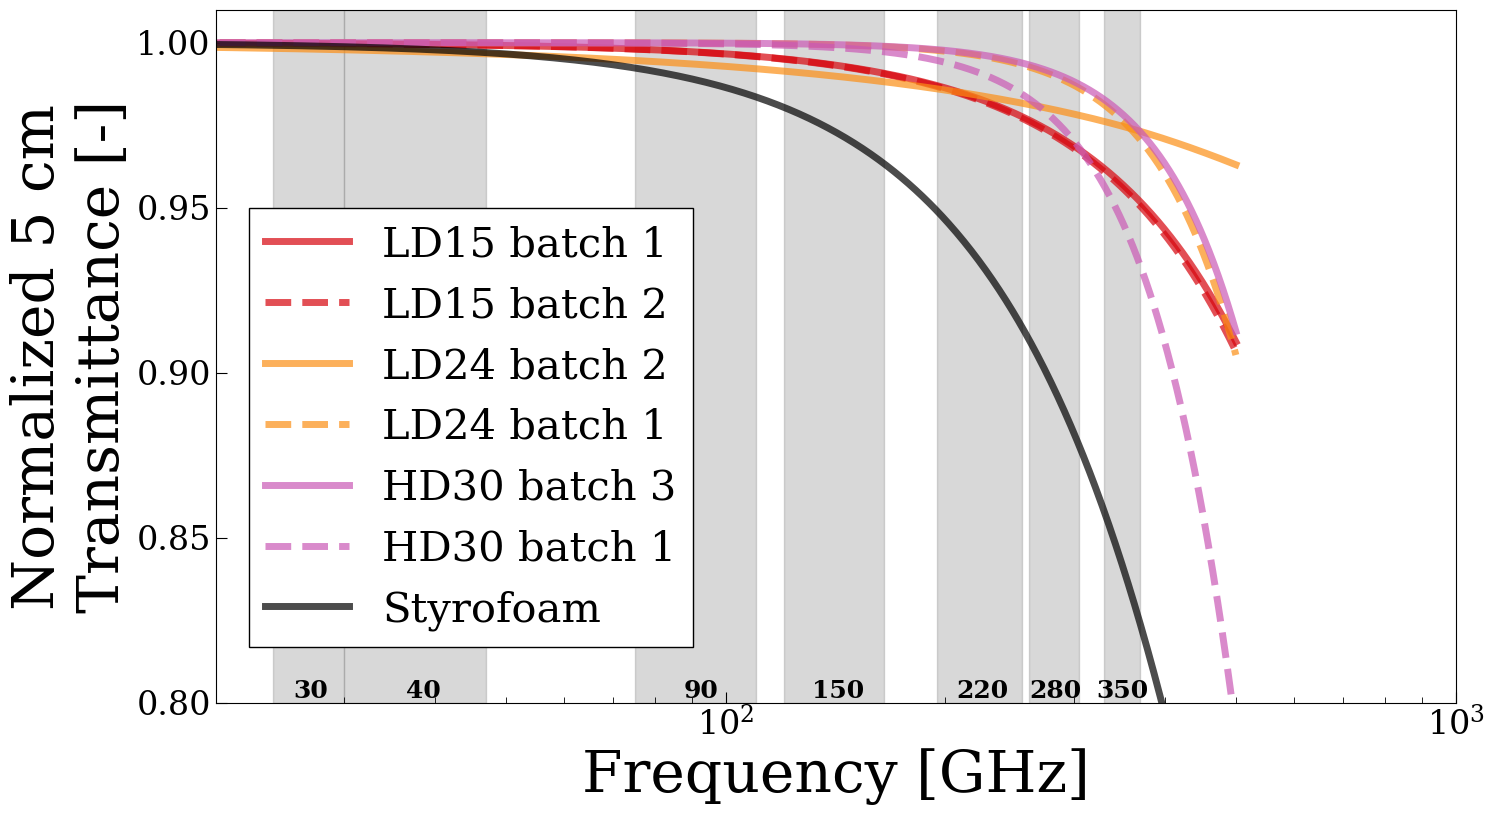

In [101]:
DISPLAY_MAP2 = {

    "LD15 batch1 2.65 cm": ["LD15 batch 1", colors2[0], '-'],
    "LD15 batch2 0.30 cm": ["LD15 batch 2", colors2[0], '--'],
    "LD24 batch2 0.34 cm": ["LD24 batch 2", colors2[1], '-'],
    "LD24 batch1 2.60 cm": ["LD24 batch 1", colors2[1], '--'],
    "HD30_batch3": ["HD30 batch 3", comb_batches['HD30_batch1']['color'], '-'],
    "HD30_batch1": ["HD30 batch 1", comb_batches['HD30_batch1']['color'], '--'],
    "Styrofoam_batch": ["Styrofoam", 'k', '-'],
}

fig, ax = plt.subplots(figsize=(16, 9), dpi=100)

# Plot measurements and fits
for bname in DISPLAY_MAP2.keys():
    b = comb_batches[bname]
    label, color, ls = DISPLAY_MAP2[bname]

    ns_T = b['ns_T_5cm']

    plt.plot(f, ns_T, color=color, lw=5, label=label, linestyle=ls, alpha=0.7)

handles = ax.get_legend_handles_labels()[0]

xticks = []
for band, (i, j) in band_windows_full.items():
    plt.axvspan(i, j, color='gray', alpha=0.3)
    plt.text((i+j)/2, 0.80, band, horizontalalignment='center', verticalalignment='bottom', fontsize=18, color='black', fontweight='bold')

ax.legend(handles=handles, loc='lower left', bbox_to_anchor=(0.01, 0.05), fontsize=30, edgecolor='black', facecolor='white', framealpha=1, fancybox=False)

plt.xlim(20, 1000)
ax.yaxis.set_major_locator(MultipleLocator(0.05))
plt.ylim(0.8, 1.01)
plt.xscale('log')

plt.xlabel('Frequency [GHz]', fontsize=42)
plt.ylabel('Normalized 5 cm\nTransmittance [-]', fontsize=42)
plt.gcf().set_facecolor('white')
# plt.savefig('5cm_spectra-c.pdf', bbox_inches='tight', facecolor='white')
plt.show()

In [102]:
rows = []

header = ["Sample"] + [f"T{band} [%]" for band in band_windows_full.keys()]

rows.append(dict(zip(header, header)))

for bname, b in list(comb_batches.items()):
    if bname not in ['Styrofoam_batch', 'LD15 batch1 2.65 cm', 'LD15 batch2 0.30 cm', 'LD24 batch1 2.60 cm', 'LD24 batch2 0.34 cm', 'HD30_batch1', 'HD30_batch2', 'HD30_batch3', 'HD80 2.58 cm', 'HD110 2.08 cm']:
        continue

    row = {"Sample": bname}
    
    T_lower, ns_T, T_upper = b['T_lower_5cm'], b['ns_T_5cm'], b['T_upper_5cm']

    # --- band-averaged transmittance ---
    for band_name, (lo_f, hi_f) in band_windows_full.items():
        sel = (f > lo_f) & (f < hi_f)

        val = 100*float(np.mean(ns_T[sel]))
        upper_val = 100*float(np.mean(T_upper[sel]))
        lower_val = 100*float(np.mean(T_lower[sel]))

        up = upper_val - val
        lo = val - lower_val

        row[f"T{band_name} [%]"] = format_unc(val, lo, up)

    rows.append(row)

df = pd.DataFrame(rows)

for _, row in df.iterrows():
    cells = [row["Sample"]] + [row[f"T{band} [%]"] for band in band_windows_full.keys()]
    print(" & ".join(cells) + r" \\")

Sample & T30 [%] & T40 [%] & T90 [%] & T150 [%] & T220 [%] & T280 [%] & T350 [%] \\
Styrofoam_batch & $99.90017^{+0.00009}_{-0.00009}$ & $99.7947^{+0.0002}_{-0.0002}$ & $98.8225^{+0.0010}_{-0.0010}$ & $97.228^{+0.002}_{-0.002}$ & $93.194^{+0.005}_{-0.005}$ & $89.441^{+0.008}_{-0.008}$ & $84.11^{+0.01}_{-0.01}$ \\
LD15 batch1 2.65 cm & $99.97521^{+0.00005}_{-0.00005}$ & $99.9490^{+0.0001}_{-0.0001}$ & $99.7059^{+0.0006}_{-0.0006}$ & $99.302^{+0.001}_{-0.001}$ & $98.247^{+0.004}_{-0.004}$ & $97.223^{+0.005}_{-0.006}$ & $95.692^{+0.008}_{-0.008}$ \\
LD15 batch2 0.30 cm & $99.9747^{+0.0002}_{-0.0002}$ & $99.9480^{+0.0004}_{-0.0004}$ & $99.700^{+0.002}_{-0.002}$ & $99.288^{+0.005}_{-0.005}$ & $98.21^{+0.01}_{-0.01}$ & $97.16^{+0.02}_{-0.02}$ & $95.58^{+0.03}_{-0.03}$ \\
LD24 batch1 2.60 cm & $99.9998^{+0.0001}_{-0.0005}$ & $99.9993^{+0.0003}_{-0.0009}$ & $99.986^{+0.001}_{-0.003}$ & $99.929^{+0.002}_{-0.006}$ & $99.573^{+0.005}_{-0.011}$ & $98.971^{+0.009}_{-0.013}$ & $97.62^{+0.02}_{-0.02}

# Estimating Cell Sizes

In [103]:
# Physical constants and parameters
C     = comb_batches['HD30_batch3']['params'][1] # 1/cm
K_Ray = comb_batches['HD30_batch3']['params'][2] # GHz
K_Mie = comb_batches['HD30_batch3']['params'][3] # GHz

c = 3e8 #m/s
n_m = 1.54
n_p = 1.0003
m = n_p/n_m
m2 = m**2
f_c = 0.975

d= 400*1e-6 # from manufacturer, 440 um from EDW


d_Mie = 100*C*c**2/(6*f_c*(n_m*np.pi*K_Mie*1e9*(m-1))**2)
d_Ray = (100*C/(4*f_c) * (c/(n_m*np.pi * K_Ray*1e9))**4 * np.abs((m2+2)/(m2-1))**2)**(1/3)
l_Ray = c/(n_m*np.pi*K_Ray*1e9) * ((100*C*d_Mie)/(8*f_c))**(1/4) * np.abs((m2+2)/(m2-1))**(1/2)


print(f"""For {C:.4e} cm^-1, K_Ray = {K_Ray:.4f} GHz, K_Mie = {K_Mie:.4f} GHz we find:
- Mie diameter: {d_Mie*1e6:.3f} um
- Rayleigh diameter: {d_Ray*1e6:.3f} um
- Rayleigh wall thickness (assuming Mie diameter cells): {l_Ray*1e6:.1f} um""")

For 3.1852e-04 cm^-1, K_Ray = 181.6527 GHz, K_Mie = 2824.3186 GHz we find:
- Mie diameter: 0.000 um
- Rayleigh diameter: 12.486 um
- Rayleigh wall thickness (assuming Mie diameter cells): 0.4 um


In [104]:
comb_batches['LD15 batch1 2.65 cm']['cell_size'] = 380e-6
comb_batches['LD15 batch2 0.30 cm']['cell_size'] = 380e-6
comb_batches['LD24 batch1 2.60 cm']['cell_size'] = 300e-6
comb_batches['LD24 batch2 0.34 cm']['cell_size'] = 300e-6
comb_batches['HD30_batch1']['cell_size']  = 400e-6
comb_batches['HD30_batch2']['cell_size']  = 400e-6
comb_batches['HD30_batch3']['cell_size']  = 400e-6
comb_batches['HD60 2.03 cm']['cell_size'] = 400e-6
comb_batches['HD80 2.58 cm']['cell_size'] = 600e-6
comb_batches['HD110 2.08 cm']['cell_size'] = 1050e-6

rows = []

def Mie_eff_diameter(C, K_Mie_GHz, f_c, n_m, n_p=n_p, c=3e8):
    m = n_p/n_m
    return 100*C * c**2 / (6*f_c*(n_m*np.pi*K_Mie_GHz*1e9*(m-1))**2)

def Ray_eff_diameter(C, K_Ray_GHz, f_c, n_m, n_p=n_p, c=3e8):
    m = n_p/n_m
    return (100*C/(4*f_c) * (c/(n_m*np.pi*K_Ray_GHz*1e9))**4 * np.abs((m2+2)/(m2-1))**2)**(1/3)

def Ray_eff_thickness(C, K_Ray_GHz, d_Mie, f_c, n_m, n_p=n_p, c=3e8):
    m = n_p/n_m
    return c/(n_m*np.pi*K_Ray_GHz*1e9) * ((100*C*d_Mie)/(8*f_c))**(1/4) * np.abs((m2+2)/(m2-1))**(1/2)

def wall_thickness(d, f_c): #theoretical wall thickness based on cell size and volume fraction
    return d/2 * (1 - f_c**(1/3))

for bname, b in comb_batches.items():
    if 'HD' not in bname and 'LD' not in bname:
        continue

    density = b['density']

    rho_m = 950 if 'HD' in bname else (925 if 'LD' in bname else None)
    n_m   = 1.54 if 'HD' in bname else (1.514 if 'LD' in bname else None)
    f_m = f_m_from_rho(density, rho_m)
    f_c = 1 - f_m
    
    C     = b['params'][1]
    K_Ray = b['params'][2]
    K_Mie = b['params'][3]

    d_Mie = Mie_eff_diameter(C, K_Mie, f_c, n_m)
    d_Ray = Ray_eff_diameter(C, K_Ray, f_c, n_m)
    l_Ray = Ray_eff_thickness(C, K_Ray, d_Mie, f_c, n_m)

    l_th  = wall_thickness(b['cell_size'], f_c)

    rows.append({
        "sample": bname,
        "density [kg/m^3]": b["density"],
        "Cell Size [um]": b["cell_size"] * 1e6,
        "d_Mie [um]": d_Mie * 1e6,
        "d_Ray [um]": d_Ray * 1e6,
        "l_Ray [um]": l_Ray * 1e6,
        "l_th [um]": l_th * 1e6,
        "l/d": l_th*1e6/b["density"]
    })

df = pd.DataFrame(rows).set_index("sample").sort_values("density [kg/m^3]")
df

,density [kg/m^3],Cell Size [um],d_Mie [um],d_Ray [um],l_Ray [um],l_th [um],l/d
sample,,,,,,,
LD15 batch1 2.65 cm,15.0,380.0,0.079251,6.159003,1.744319,0.947432,0.063162
LD15 batch2 0.30 cm,15.0,380.0,0.080647,6.489842,1.822072,0.947432,0.063162
LD24 batch1 2.60 cm,24.0,300.0,0.000097,13.122458,0.575496,1.241643,0.051735
LD24 batch2 0.34 cm,24.0,300.0,0.000091,0.648612,0.059400,1.241643,0.051735
HD30_batch1,30.0,400.0,0.000018,17.096252,0.458451,2.040959,0.068032
HD30_batch2,30.0,400.0,0.000045,15.686873,0.542232,2.040959,0.068032
HD30_batch3,30.0,400.0,0.000021,12.508340,0.380787,2.040959,0.068032
HD60 2.03 cm,60.0,400.0,0.342897,20.770987,6.260748,4.216509,0.070275
HD80 2.58 cm,80.0,600.0,0.000048,30.943867,0.916826,8.541265,0.106766


# Custom loss plots

Secondary scattering matters for HD110 in band, matters for HD80 after ~300 GHz.

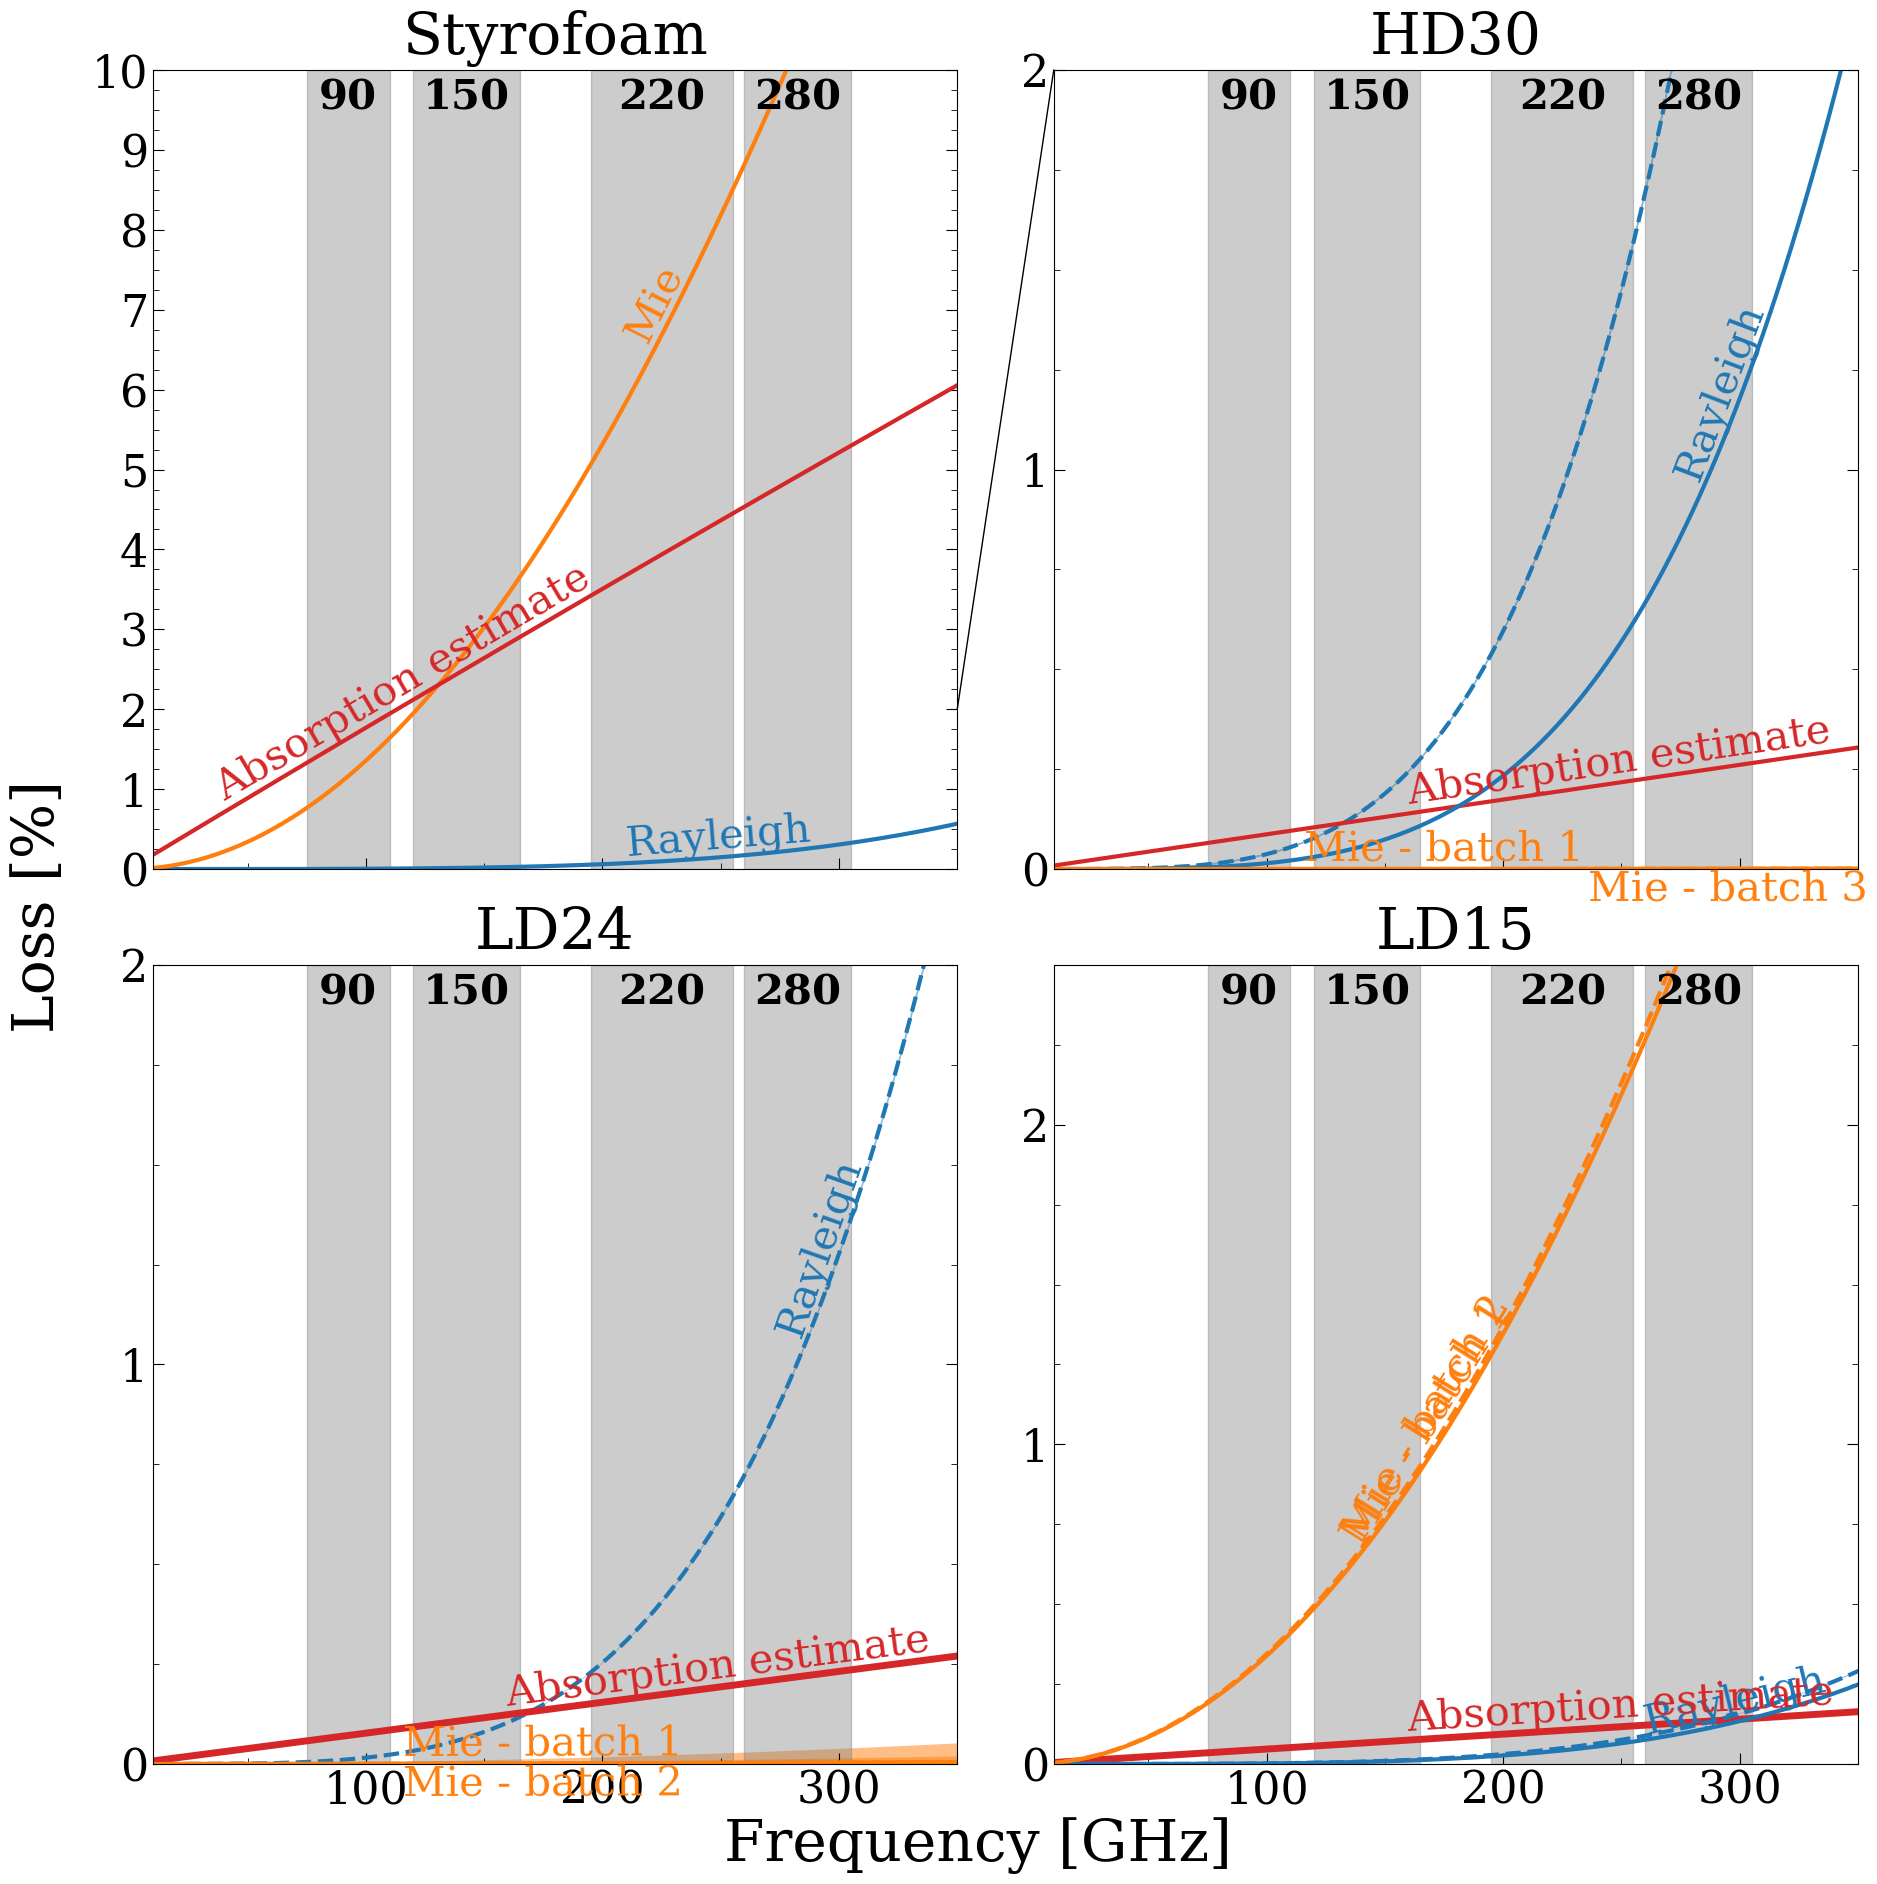

In [105]:
from matplotlib.patches import ConnectionPatch

fig, axes = plt.subplots(2, 2, figsize=(22, 22), sharex=True)
ax0, ax1, ax2, ax3 = axes.flatten()

for ax in axes.flatten():
    ax.set_rasterization_zorder(1)

## Styrofoam Batches

bname = 'Styrofoam_batch'
b = comb_batches[bname]

ax0.set_xlim(10, 350)
ax0.set_ylim(0, 10)

Abs, Abs_upper, Abs_lower, Abs_color, _ = b["estimates"]["Abs"].values()
Ray, Ray_upper, Ray_lower, Ray_color, _ = b["estimates"]["Ray"].values()
Mie, Mie_upper, Mie_lower, Mie_color, _ = b["estimates"]["Mie"].values()

ax0.plot(f, Ray, color=Ray_color, lw=3,  zorder=2)
ax0.plot(f, Mie, color=Mie_color, lw=3, zorder=2)
ax0.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, alpha=0.5, zorder=0)
ax0.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, alpha=0.5, zorder=0)

ax0.plot(f, Abs, color=Abs_color, lw=3, zorder=2)

fig.canvas.draw()
for freq, arr, label, color in [
    (230, Mie, 'Mie', Mie_color),
    (250, Ray, 'Rayleigh', Ray_color),
    (120, Abs, 'Absorption estimate', Abs_color)
]:
    idx = np.argmin(np.abs(f - freq))
    p0 = ax0.transData.transform((f[idx-10], arr[idx-10]))
    p1 = ax0.transData.transform((f[idx+10], arr[idx+10]))
    angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
    ax0.text(f[idx], arr[idx], label, color=color, fontsize=30,
                ha='center', va='bottom', rotation=angle, rotation_mode='anchor')

ax0.set_title('Styrofoam', y=1.01, fontsize=42)

## HD30 Batches
j = 0
linestyles = ['--', '-']

for bname, b in comb_batches.items():
    if bname not in ['HD30_batch1', 'HD30_batch3']:
        continue
    batch_num = bname.split('_')[-1][-1]

    ax1.set_xlim(10, 350)
    ax1.set_ylim(0, 2)

    Abs, Abs_upper, Abs_lower, Abs_color, _ = b["estimates"]["Abs"].values()
    Ray, Ray_upper, Ray_lower, Ray_color, _ = b["estimates"]["Ray"].values()
    Mie, Mie_upper, Mie_lower, Mie_color, _ = b["estimates"]["Mie"].values()

    ax1.plot(f, Ray, color=Ray_color, lw=3, ls=linestyles[j], zorder=2)
    ax1.plot(f, Mie, color=Mie_color, lw=3, ls=linestyles[j], zorder=2)
    ax1.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, alpha=0.5, zorder=0)
    ax1.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, alpha=0.5, zorder=0)

    if j == 0:
        ax1.plot(f, Abs, color=Abs_color, lw=3, zorder=2)

    fig.canvas.draw()

    if j == 1:
        idx = np.argmin(np.abs(f - 295))
        p0 = ax1.transData.transform((f[idx-10], Mie[idx-10]))
        p1 = ax1.transData.transform((f[idx+10], Mie[idx+10]))
        angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
        ax1.text(f[idx], Mie[idx], f"Mie - batch {batch_num}", color=Mie_color, fontsize=30,
                ha='center', va='top', rotation=angle, rotation_mode='anchor')
        
        idx = np.argmin(np.abs(f - 300))
        p0 = ax1.transData.transform((f[idx-10], Ray[idx-10]))
        p1 = ax1.transData.transform((f[idx+10], Ray[idx+10]))
        angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
        ax1.text(f[idx], Ray[idx], "Rayleigh", color=Ray_color, fontsize=30,
                 ha='center', va='bottom', rotation=angle, rotation_mode='anchor')

        idx = np.argmin(np.abs(f - 250))
        p0 = ax1.transData.transform((f[idx-10], Abs[idx-10]))
        p1 = ax1.transData.transform((f[idx+10], Abs[idx+10]))
        angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
        ax1.text(f[idx], Abs[idx], "Absorption estimate", color=Abs_color, fontsize=30,
                 ha='center', va='bottom', rotation=angle, rotation_mode='anchor')
    else:
        idx = np.argmin(np.abs(f - 175))
        p0 = ax1.transData.transform((f[idx-10], Mie[idx-10]))
        p1 = ax1.transData.transform((f[idx+10], Mie[idx+10]))
        angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
        ax1.text(f[idx], Mie[idx], f"Mie - batch {batch_num}", color=Mie_color, fontsize=30,
             ha='center', va='bottom', rotation=angle, rotation_mode='anchor')
        
    j += 1

ax1.set_title('HD30', y=1.01, fontsize=42)

## LD24
bname = 'LD24 batch1 2.60 cm'
b = comb_batches[bname]
display_name = DISPLAY_MAP.get(bname, bname)

ax2.set_xlim(10, 350)
ax2.set_ylim(0, 2)

Abs, Abs_upper, Abs_lower, Abs_color, Abs_ls  = b["estimates"]["Abs"].values()
Ray, Ray_upper, Ray_lower, Ray_color, Ray_ls  = b["estimates"]["Ray"].values()
Mie, Mie_upper, Mie_lower, Mie_color, Mie_ls  = b["estimates"]["Mie"].values()

ax2.plot(f, Ray, color=Ray_color, lw=3, linestyle=linestyles[0], zorder=2)
ax2.plot(f, Mie, color=Mie_color, lw=3, linestyle=linestyles[0], zorder=2)
ax2.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, edgecolor='none', alpha=0.5, zorder=0)
ax2.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, edgecolor='none', alpha=0.5, zorder=0)

fig.canvas.draw()
for freq, arr, label, color, fs, va in [
    (175, Mie, 'Mie - batch 1',       Mie_color, 30, 'bottom'),
    (300, Ray, 'Rayleigh',            Ray_color, 30, 'bottom'),
    (250, Abs, 'Absorption estimate', Abs_color, 30, 'bottom'),
]:
    idx = np.argmin(np.abs(f - freq))
    p0 = ax2.transData.transform((f[idx-10], arr[idx-10]))
    p1 = ax2.transData.transform((f[idx+10], arr[idx+10]))
    angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
    ax2.text(freq, arr[idx], label, color=color, fontsize=fs, ha='center', va=va, rotation=angle, rotation_mode='anchor')

ax2.set_title(bname.split()[0], y=1.01, fontsize=42)

bname = 'LD24 batch2 0.34 cm'
b = comb_batches[bname]
display_name = DISPLAY_MAP.get(bname, bname)

Abs, Abs_upper, Abs_lower, Abs_color, Abs_ls  = b["estimates"]["Abs"].values()
Ray, Ray_upper, Ray_lower, Ray_color, Ray_ls  = b["estimates"]["Ray"].values()
Mie, Mie_upper, Mie_lower, Mie_color, Mie_ls  = b["estimates"]["Mie"].values()

ax2.plot(f, Abs, color=Abs_color, lw=5, linestyle=linestyles[1], zorder=2)
ax2.plot(f, Ray, color=Ray_color, lw=3, linestyle=linestyles[1], zorder=2)
ax2.plot(f, Mie, color=Mie_color, lw=3, linestyle=linestyles[1], zorder=2)
ax2.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, edgecolor='none', alpha=0.5, zorder=0)
ax2.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, edgecolor='none', alpha=0.5, zorder=0)

fig.canvas.draw()
for freq, arr, label, color, fs, va in [(175, Mie, 'Mie - batch 2', Mie_color, 30, 'top')]:
    idx = np.argmin(np.abs(f - freq))
    p0 = ax2.transData.transform((f[idx-10], arr[idx-10]))
    p1 = ax2.transData.transform((f[idx+10], arr[idx+10]))
    angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
    ax2.text(freq, arr[idx], label, color=color, fontsize=fs, ha='center', va=va, rotation=angle, rotation_mode='anchor')

## LD15
bname = 'LD15 batch1 2.65 cm'
b = comb_batches[bname]

ax3.set_xlim(10, 350)
ax3.set_ylim(0, 2.5)

Abs, Abs_upper, Abs_lower, Abs_color, Abs_ls  = b["estimates"]["Abs"].values()
Ray, Ray_upper, Ray_lower, Ray_color, Ray_ls  = b["estimates"]["Ray"].values()
Mie, Mie_upper, Mie_lower, Mie_color, Mie_ls  = b["estimates"]["Mie"].values()

ax3.plot(f, Abs, color=Abs_color, lw=5, linestyle=linestyles[1], zorder=2)
ax3.plot(f, Ray, color=Ray_color, lw=3, linestyle=linestyles[1], zorder=2)
ax3.plot(f, Mie, color=Mie_color, lw=3, linestyle=linestyles[1], zorder=2)
ax3.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, edgecolor='none', alpha=0.5, zorder=0)
ax3.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, edgecolor='none', alpha=0.5, zorder=0)

fig.canvas.draw()
for freq, arr, label, color, fs, va in [
    (175, Mie, 'Mie - batch 1',       Mie_color, 30, 'bottom'),
    (300, Ray, 'Rayleigh',            Ray_color, 30, 'bottom'),
    (250, Abs, 'Absorption estimate', Abs_color, 30, 'bottom'),
]:
    idx = np.argmin(np.abs(f - freq))
    p0 = ax3.transData.transform((f[idx-10], arr[idx-10]))
    p1 = ax3.transData.transform((f[idx+10], arr[idx+10]))
    angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
    ax3.text(freq, arr[idx], label, color=color, fontsize=fs, ha='center', va=va, rotation=angle, rotation_mode='anchor', zorder=10)


bname = 'LD15 batch2 0.30 cm'
b = comb_batches[bname]

Abs, Abs_upper, Abs_lower, Abs_color, Abs_ls  = b["estimates"]["Abs"].values()
Ray, Ray_upper, Ray_lower, Ray_color, Ray_ls  = b["estimates"]["Ray"].values()
Mie, Mie_upper, Mie_lower, Mie_color, Mie_ls  = b["estimates"]["Mie"].values()

ax3.plot(f, Ray, color=Ray_color, lw=3, linestyle=linestyles[0], zorder=2)
ax3.plot(f, Mie, color=Mie_color, lw=3, linestyle=linestyles[0], zorder=2)
ax3.fill_between(f, Ray_upper, Ray_lower, color=Ray_color, edgecolor='none', alpha=0.5, zorder=0)
ax3.fill_between(f, Mie_upper, Mie_lower, color=Mie_color, edgecolor='none', alpha=0.5, zorder=0)

fig.canvas.draw()
for freq, arr, label, color, fs, va in [(175, Mie, 'Mie - batch 2', Mie_color, 30, 'bottom'),
]:
    idx = np.argmin(np.abs(f - freq))
    p0 = ax3.transData.transform((f[idx-10], arr[idx-10]))
    p1 = ax3.transData.transform((f[idx+10], arr[idx+10]))
    angle = np.degrees(np.arctan2(p1[1]-p0[1], p1[0]-p0[0]))
    ax3.text(freq, arr[idx], label, color=color, fontsize=fs, ha='center', va=va, rotation=angle, rotation_mode='anchor', zorder=10)

ax3.set_title(bname.split()[0], y=1.01, fontsize=42)

## General
for ax in axes.flatten():
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.25))
    ax.xaxis.set_major_locator(MultipleLocator(100))
    ax.xaxis.set_minor_locator(MultipleLocator(50))
    ax.tick_params(axis='both', which='major', labelsize=32)
    ax.tick_params(axis='y', which='both', left=True, right=True)
    for band, (lbound, ubound) in band_windows_full.items():
        if band not in ["90", "150", "220", "280"]:
            continue
        band_center = (lbound + ubound) / 2
        ax.text(band_center, 0.99*ax.get_ylim()[1], band, color='k', ha='center', va='top', fontsize=30, fontweight='bold')
        ax.axvspan(lbound, ubound, alpha=0.4, color='gray', zorder=0)

fig.supxlabel('Frequency [GHz]', fontsize=42, y=0.06)
fig.supylabel('Loss [%]', fontsize=42, x=0.06)
plt.subplots_adjust(hspace=0.12, wspace=0.12)

con = ConnectionPatch(
    xyA=(0, 2), coordsA=ax1.get_yaxis_transform(),
    xyB=(1, 2), coordsB=ax0.get_yaxis_transform(),
    color="k", linewidth=1
)
fig.add_artist(con)

plt.gcf().set_facecolor('white')
# plt.savefig('components.pdf', bbox_inches='tight', facecolor='white')
plt.show()

In [106]:
Ray1 = next(iter(comb_batches['HD30_batch1']["estimates"]["Ray"].values()))
Ray2 = next(iter(comb_batches['HD30_batch2']["estimates"]["Ray"].values()))
Ray3 = next(iter(comb_batches['HD30_batch3']["estimates"]["Ray"].values()))

Mie1 = next(iter(comb_batches['HD30_batch1']["estimates"]["Mie"].values()))
Mie2 = next(iter(comb_batches['HD30_batch2']["estimates"]["Mie"].values()))
Mie3 = next(iter(comb_batches['HD30_batch3']["estimates"]["Mie"].values()))

Rays = np.array([Ray1, Ray2, Ray3])
Mies = np.array([Mie1, Mie2, Mie3])

idx = np.argmin(np.abs(f - 280))
min_key = np.argmin(Rays[:, idx])
max_key = np.argmax(Rays[:, idx])

min_sigma = (comb_batches[f'HD30_batch{min_key+1}']["estimates"]["Ray"]['upper'][idx] - comb_batches[f'HD30_batch{min_key+1}']["estimates"]["Ray"]['lower'][idx]) / 2
max_sigma = (comb_batches[f'HD30_batch{max_key+1}']["estimates"]["Ray"]['upper'][idx] - comb_batches[f'HD30_batch{max_key+1}']["estimates"]["Ray"]['lower'][idx]) / 2

print(f"At 280 GHz, min Rayleigh is Batch {min_key+1} with value {Rays[min_key, idx]:.4f} ± {min_sigma:.4f}, max Rayleigh is Batch {max_key+1} with value {Rays[max_key, idx]:.4f} ± {max_sigma:.4f}, difference: {(Rays[max_key, idx] - Rays[min_key, idx]):.4f} ± {(min_sigma**2 + max_sigma**2)**0.5:.4f}")
      
min_key = np.argmin(Mies[:, idx])
max_key = np.argmax(Mies[:, idx])

min_sigma = (comb_batches[f'HD30_batch{min_key+1}']["estimates"]["Mie"]['upper'][idx] - comb_batches[f'HD30_batch{min_key+1}']["estimates"]["Mie"]['lower'][idx]) / 2
max_sigma = (comb_batches[f'HD30_batch{max_key+1}']["estimates"]["Mie"]['upper'][idx] - comb_batches[f'HD30_batch{max_key+1}']["estimates"]["Mie"]['lower'][idx]) / 2

print(f"At 280 GHz, min Mie is Batch {min_key+1} with value {Mies[min_key, idx]:.4f} ± {min_sigma:.4f}, max Mie is Batch {max_key+1} with value {Mies[max_key, idx]:.4f} ± {max_sigma:.4f}, difference: {(Mies[max_key, idx] - Mies[min_key, idx]):.4f} ± {(min_sigma**2 + max_sigma**2)**0.5:.4f}")

At 280 GHz, min Rayleigh is Batch 3 with value 0.8950 ± -0.0015, max Rayleigh is Batch 1 with value 2.2693 ± -0.0010, difference: 1.3743 ± 0.0018
At 280 GHz, min Mie is Batch 1 with value 0.0006 ± 0.0004, max Mie is Batch 2 with value 0.0016 ± 0.0019, difference: 0.0010 ± 0.0019


In [107]:
# =============================================================================
# Excess optical loading from 273 K blackbody scattered into 40-90 deg
# =============================================================================
# The scattering fractions Ray(f) and Mie(f) [in %] give what fraction of the
# beam is redirected per unit path by Rayleigh / Mie scattering.  The phase
# function P(theta) tells us what fraction of that scattered power lands in a
# given solid-angle wedge.  We integrate P from 40 to 90 deg to get F_Ray and
# F_Mie(f) -- the fraction heading into the warm (273 K) environment.
# Loading per band:  P = k * T_bb * <scatter_frac * F_angular> * delta_nu
# =============================================================================

from scipy.special import spherical_jn as _sjn

# Riccati-Bessel functions
def _psi(n, x):       return x * _sjn(n, x)
def _psi_p(n, x):     return _sjn(n, x) + x * _sjn(n, x, derivative=True)

# Thin-shell Mie Coefficients
def _ab_shell(n, m, x, delta):
    p, pp = _psi(n, x), _psi_p(n, x)
    bn = -1j * delta * (m**2 - 1) * p**2
    an = -1j * delta * (n*(n+1)*(m**2-1)/(m**2*x**2) * p**2 + (m**2-1)*pp**2)
    return an, bn

# Pi and Tau
def _pi_tau(nmax, tr):
    ct = np.cos(tr)
    PA, TA = np.zeros((nmax, len(tr))), np.zeros((nmax, len(tr)))
    pp, p  = np.zeros(len(tr)), np.ones(len(tr))
    for n in range(1, nmax+1):
        TA[n-1] = n*ct*p - (n+1)*pp;  PA[n-1] = p
        pp, p   = p, ((2*n+1)*ct*p - (n+1)*pp) / n
    return PA, TA

# Phase function for thin-shell Mie scattering
def _phase(al, bl, tr):
    PA, TA = _pi_tau(len(al), tr)
    S1 = np.zeros(len(tr), dtype=complex)
    S2 = np.zeros(len(tr), dtype=complex)
    for n, (a, b) in enumerate(zip(al, bl), 1):
        fac = (2*n+1)/(n*(n+1))
        S1 += fac*(a*PA[n-1]+b*TA[n-1])
        S2 += fac*(b*PA[n-1]+a*TA[n-1])
    P = (np.abs(S1)**2 + np.abs(S2)**2) / 2
    return P / (np.trapezoid(P*np.sin(tr), tr) * 2*np.pi)  # int_4pi = 1

# ---- Angular grid ----------------------------------------------------------
th_deg = np.linspace(0, 180, 181)
th_rad = np.deg2rad(th_deg)
th_rad[0] = 1e-6;  th_rad[-1] = np.pi - 1e-6
m40_90 = (th_deg >= 40) & (th_deg <= 90)   # mask: warm-environment wedge

# ---- Rayleigh fraction in 40-90 deg (frequency-independent) ---------------
P_ray = (3/(16*np.pi)) * (1 + np.cos(th_rad)**2)
F_Ray = 2*np.pi * np.trapezoid(P_ray[m40_90]*np.sin(th_rad[m40_90]), th_rad[m40_90])
print(f'Rayleigh fraction in 40-90 deg: {100*F_Ray:.1f}% of scattered power')

# ---- Thin-shell Mie fraction in 40-90 deg, vs frequency -------------------
c_mie   = 30.0    # GHz*cm
m_mie   = 1.54    # n_p / n_m  (n_m=1, n_p=1.54)
d_mie   = 400e-4  # cm  (400 um cell diameter)
ell_mie = 2e-4    # cm  (2 um wall thickness)
N_mul   = 30

# Compute on a coarse 10-GHz grid, then interpolate to the 1-GHz f array
F_Mie = np.empty(len(f))
for _i, _f in enumerate(f):
    _x  = np.pi * d_mie * _f / c_mie
    _dlt = np.pi * ell_mie * _f / c_mie
    _al, _bl = zip(*[_ab_shell(_n, m_mie, _x, _dlt) for _n in range(1, N_mul+1)])
    _P = _phase(list(_al), list(_bl), th_rad)
    F_Mie[_i] = 2*np.pi * np.trapezoid(_P[m40_90]*np.sin(th_rad[m40_90]), th_rad[m40_90])
print(f'Mie fraction in 40-90 deg: {100*F_Mie[np.argmin(np.abs(f-90))]:.1f}% at 90 GHz, '
      f'{100*F_Mie[np.argmin(np.abs(f-280))]:.1f}% at 280 GHz')

# ---- Loading calculation ---------------------------------------------------
from scipy.constants import k as k_B
T_bb   = 273.0    # K  (room-temperature blackbody)
Npol   = 1        # one polarization

# Samples: (display name, dict, estimates key)
DISPLAY_MAP3 = [
    ('Styrofoam',    comb_batches['Styrofoam_batch']),
    ('HD30 batch 1', comb_batches['HD30_batch1']),
    ('HD30 batch 2', comb_batches['HD30_batch2']),
    (r'HD30 batch 3$^\dagger$', comb_batches['HD30_batch3']),
    ('LD24 batch 1', comb_batches['LD24 batch1 2.60 cm']),
    (r'LD24 batch 2$^\dagger$', comb_batches['LD24 batch2 0.34 cm']),
    (r'LD15 batch 1$^\dagger$', comb_batches['LD15 batch1 2.65 cm']),
    ('LD15 batch 2', comb_batches['LD15 batch2 0.30 cm']),
]

band_list  = ['90', '150', '220', '280']
bandwidths = [35.0, 45.0, 45.0, 65.0]   

hdr = f"{'Sample':<28}  {'Band':>4}  {'P_Ray[pW]':>10}  {'P_Mie[pW]':>10}  {'P_tot[pW]':>10}"

for disp_name, b in DISPLAY_MAP3:
    row_entries_odd = [f"\\multirow{{2}}{{*}}{{{disp_name}}}"]
    row_entries_even = ['']

    # The estimates are stored such that highest transmission is "upper", we invert the defintion explicitly here
    Ray_arr   = b['estimates']['Ray']['arr']
    Ray_lower = b['estimates']['Ray']['upper'] 
    Ray_upper = b['estimates']['Ray']['lower']

    Mie_arr   = b['estimates']['Mie']['arr']
    Mie_lower = b['estimates']['Mie']['upper']
    Mie_upper = b['estimates']['Mie']['lower']

    for i, (band, dnu) in enumerate(zip(bands, bandwidths)):
        row_entries = row_entries_odd if i % 2 == 0 else row_entries_even

        lo_f, hi_f = band_windows_full[band]
        dnu        = bandwidths[i]           # GHz
        sel        = (f > lo_f) & (f < hi_f)

        Ray_frac    = np.mean(Ray_arr[sel]) / 100.0
        Mie_frac    = np.mean(Mie_arr[sel]) / 100.0

        F_Mie_band  = np.mean(F_Mie[sel])

        # Optical loading calculation
        P_Ray       = Npol * k_B * T_bb * np.mean((Ray_arr[sel]/100.0)   * F_Ray) * dnu * 1e21
        P_Ray_lower = Npol * k_B * T_bb * np.mean((Ray_lower[sel]/100.0) * F_Ray) * dnu * 1e21
        P_Ray_upper = Npol * k_B * T_bb * np.mean((Ray_upper[sel]/100.0) * F_Ray) * dnu * 1e21
        P_Mie       = Npol * k_B * T_bb * np.mean((Mie_arr[sel]/100.0)   * F_Mie[sel]) * dnu * 1e21
        P_Mie_lower = Npol * k_B * T_bb * np.mean((Mie_lower[sel]/100.0) * F_Mie[sel]) * dnu * 1e21
        P_Mie_upper = Npol * k_B * T_bb * np.mean((Mie_upper[sel]/100.0) * F_Mie[sel]) * dnu * 1e21

        # Relative uncertainties
        P_Ray_lower = P_Ray-P_Ray_lower
        P_Ray_upper = P_Ray_upper-P_Ray
        P_Mie_lower = P_Mie - P_Mie_lower
        P_Mie_upper = P_Mie_upper - P_Mie

        # Total optical loading from scattering 
        P_scatter = P_Ray + P_Mie
        P_scatter_lower = np.sqrt(P_Ray_lower**2 + P_Mie_lower**2)
        P_scatter_upper = np.sqrt(P_Ray_upper**2 + P_Mie_upper**2)

        # formatters
        P_Ray_formatted = format_unc(P_Ray, P_Ray_lower, P_Ray_upper)
        P_Mie_formatted = format_unc(P_Mie, P_Mie_lower, P_Mie_upper)
        P_scatter_formatted = format_unc(P_scatter, P_scatter_lower, P_scatter_upper)

        row_entries.extend([P_scatter_formatted])

        # Optical loading from filter emission
        Abs = float(b['band_avgs'][(band, 'Abs')])
        T_RJ = Tphys * Abs / 100         #Temperature in K; converts from % to fraction
        P_ems = Npol * k * T_RJ * dnu * 1e21 #Power in pW; convert GHz → Hz and Watts → pW
        P_tot = P_scatter + P_ems
        
        P_tot_lower = np.sqrt(P_scatter_lower**2 + (P_ems)**2) # Assume order unity uncertainty
        P_tot_upper = np.sqrt(P_scatter_upper**2 + (P_ems)**2)
        row_entries.extend([format_val(P_ems), format_unc(P_tot, P_tot_lower, P_tot_upper)])

    print(" & ".join(row_entries_odd) + r" \\")
    print(" & ".join(row_entries_even) + r" \\[6pt]")

Rayleigh fraction in 40-90 deg: 34.3% of scattered power
Mie fraction in 40-90 deg: 35.9% at 90 GHz, 47.7% at 280 GHz
\multirow{2}{*}{Styrofoam} & $0.56107^{+0.00006}_{-0.00004}$ & $2.16$ & $3^{+2}_{-2}$ & $5.0801^{+0.0007}_{-0.0004}$ & $6.68$ & $12^{+7}_{-7}$ \\
 & $1.8088^{+0.0002}_{-0.0001}$ & $4.26$ & $6^{+4}_{-4}$ & $12.310^{+0.002}_{-0.001}$ & $12.05$ & $20^{+10}_{-10}$ \\[6pt]
\multirow{2}{*}{HD30 batch 1} & $0.01326^{+0.00002}_{-0.00004}$ & $0.11$ & $0.1^{+0.1}_{-0.1}$ & $0.5740^{+0.0008}_{-0.0004}$ & $0.33$ & $0.9^{+0.3}_{-0.3}$ \\
 & $0.0940^{+0.0001}_{-0.0001}$ & $0.21$ & $0.3^{+0.2}_{-0.2}$ & $2.002^{+0.003}_{-0.001}$ & $0.60$ & $2.6^{+0.6}_{-0.6}$ \\[6pt]
\multirow{2}{*}{HD30 batch 2} & $0.01030^{+0.00004}_{-0.00016}$ & $0.11$ & $0.1^{+0.1}_{-0.1}$ & $0.4445^{+0.0004}_{-0.0017}$ & $0.33$ & $0.8^{+0.3}_{-0.3}$ \\
 & $0.0728^{+0.0001}_{-0.0005}$ & $0.21$ & $0.3^{+0.2}_{-0.2}$ & $1.5519^{+0.0009}_{-0.0046}$ & $0.60$ & $2.2^{+0.6}_{-0.6}$ \\[6pt]
\multirow{2}{*}{HD30 batch 3$^